In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.19


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need

from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.stan.invT import predict_temperature_from_RI
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial
import pygwalker as pyg

0.1.0


In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


# Set local path

In [7]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [8]:
### Regression dataset compilation
fpath = fr'{local_github_path}/data/spreadsheets'
fname = r'ds_gridded_coretop_tex_scaledRI_revised_120325.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df.head()

,match_lat_04deg,match_lon_04deg,Strains,datatype,organism_broadClass,organism_commonName,reference_name,regionName,BIT,SST,...,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled,pred_scaledRI,scaledRI_res,pred_scaledRI_23corr,scaledRI_23corr_res
0,-77.875,-40.375,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.004,-1.64841,...,-1.656110,NaN,-1.621188,-1.636017,NaN,NaN,0.433155,0.076827,0.458100,0.051882
1,-77.375,-158.375,coretop,coretop,coretop,coretop,Kim2010,Ross Sea,NaN,-1.50741,...,-1.547720,NaN,-1.586854,-1.586854,NaN,NaN,0.433286,0.004833,0.450298,-0.012179
2,-77.125,-45.375,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.007,-1.70171,...,-1.682932,NaN,-1.692642,-1.692642,NaN,NaN,0.433004,-0.022073,0.456029,-0.045099
3,-76.625,-35.375,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.008,-1.42831,...,NaN,NaN,-1.463560,-1.498910,NaN,28.343912,0.433522,-0.000180,0.455107,-0.021765
4,-76.375,-33.875,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.005,-1.74881,...,NaN,-1.640889,-1.640889,-1.651191,22.066089,22.066089,0.433114,0.014403,0.454853,-0.007335


In [9]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Calibration posteriors

In [10]:
# Save data for Stan

cul_df = gridded_combined_df[gridded_combined_df['datatype']=='culture'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
meso_df = gridded_combined_df[gridded_combined_df['datatype']=='mesocosm'].dropna(subset=['scaledRI','SST']).reset_index(drop=True)
data = {
    "N_cul": len(cul_df),
    "t_cul": cul_df['SST'].values,
    "scaledRI_cul": cul_df['scaledRI'].values,
    "N_meso": len(meso_df),
    "t_meso": meso_df['SST'].values,
    "scaledRI_meso": meso_df['scaledRI'].values,
}

stan_file_name = 'gen_logi_fixed_culmeso'
gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(data=data, 
                                        stan_file=stan_file_name,
                                        temptype='cultureT')


# Save posteriors
save_posterior(gen_logi_fixed_cul_meso_post_ds,filename_suffix="_120325")

14:50:47 - cmdstanpy - INFO - Chain [1] start processing
14:50:47 - cmdstanpy - INFO - Chain [2] start processing
14:50:47 - cmdstanpy - INFO - Chain [3] start processing
14:50:47 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: meso (from N_meso, N=16)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_culmeso.stan
✅ Compiled: gen_logi_fixed_culmeso.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nu

Chain [3] Iteration:  100 / 2000 [  5%]  (Warmup)
Chain [4] Iteration:  100 / 2000 [  5%]  (Warmup)
Chain [2] Iteration:  100 / 2000 [  5%]  (Warmup)
Chain [1] Iteration:  100 / 2000 [  5%]  (Warmup)
Chain [4] Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Chain [4] Exception: beta_lpdf: Random variable is 4.38665, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
Chain [4] If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
Chain [4] but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
Chain [4] 
Chain [2] Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
Chain [2] Exception: beta_lpdf: Random variable is 1.04144, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.st

14:50:47 - cmdstanpy - INFO - Chain [2] done processing
14:50:47 - cmdstanpy - INFO - Chain [1] done processing


Chain [3] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0.32 seconds (Warm-up)
Chain [2] 0.295 seconds (Sampling)
Chain [2] 0.615 seconds (Total)
Chain [2] 
Chain [2] 
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0.303 seconds (Warm-up)
Chain [1] 0.32 seconds (Sampling)
Chain [1] 0.623 seconds (Total)
Chain [1] 
Chain [1] 
Chain [4] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)


14:50:47 - cmdstanpy - INFO - Chain [3] done processing
14:50:47 - cmdstanpy - INFO - Chain [4] done processing
14:50:47 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 1.30823, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmeso.stan', line 41, column 2 to column 64)
	Exception: beta_lpdf: Random variable is 1.03798, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: beta_lpdf: Random variable is 1.04567, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
Exception: beta_lpdf: Random variable is 3.51764e+09, but must be in the interval [0, 1] (in

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 0.322 seconds (Warm-up)
Chain [3] 0.335 seconds (Sampling)
Chain [3] 0.657 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0.297 seconds (Warm-up)
Chain [4] 0.361 seconds (Sampling)
Chain [4] 0.658 seconds (Total)
Chain [4] 
Chain [4] 
Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT_120325.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT_120325.nc')

##### Prior Approximation

In [11]:
coretop_df = gridded_combined_df[gridded_combined_df['datatype']=='coretop'][
    gridded_combined_df['no3_sf2tc_avg']>0.0005].reset_index(drop=True)
# dropna for coretop dataset
reg_data = coretop_df[['SST', 'scaledRI', 'gdgt23ratio','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['SST'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

no3_cutoff = 1.5
data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}


stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_priorApprox_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='SST')
display(gen_logi_fixed_hier_crtp_univ_priorApprox_post_ds)
# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_univ_priorApprox_post_ds,filename_suffix="_120325")

14:50:47 - cmdstanpy - INFO - Chain [1] start processing
14:50:47 - cmdstanpy - INFO - Chain [2] start processing
14:50:47 - cmdstanpy - INFO - Chain [3] start processing
14:50:47 - cmdstanpy - INFO - Chain [4] start processing


No gdgt23ratio data passing for multivariate model; injecting zeros.
No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1423)
   GDGT23 keys in data: [] → use_gdgt23ratio = 0
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain 

14:51:00 - cmdstanpy - INFO - Chain [1] done processing


Chain [2] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [4] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 6.187 seconds (Warm-up)
Chain [1] 6.84 seconds (Sampling)
Chain [1] 13.027 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)


14:51:01 - cmdstanpy - INFO - Chain [2] done processing
14:51:01 - cmdstanpy - INFO - Chain [4] done processing


...

14:51:01 - cmdstanpy - INFO - Chain [3] done processing
14:51:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_pr

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3]  Elapsed Time: 6.775 seconds (Warm-up)
Chain [3]                7.245 seconds (Sampling)
Chain [3]                14.02 seconds (Total)
Chain [3] 
Chain [3] 


<xarray.Dataset>
Dimensions:              (draw: 1000, chain: 4)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_crtp              (chain, draw) float64 29.28 29.35 31.31 ... 29.55 31.21
    k_crtp               (chain, draw) float64 0.1508 0.1502 ... 0.1705 0.1608
    b_crtp               (chain, draw) float64 0.3685 0.3686 ... 0.39 0.3924
    Q_crtp               (chain, draw) float64 3.637 3.558 2.674 ... 3.774 2.64
    v_crtp               (chain, draw) float64 2.47 2.436 2.523 ... 2.483 2.329
    sigma_scaledRI_crtp  (chain, draw) float64 0.06578 0.06603 ... 0.06467
    inflection_point     (chain, draw) float64 35.28 35.28 37.47 ... 34.89 36.46
Attributes: (12/30)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_univ_priorApprox_m...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_univ_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00146
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1488.12
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_120325.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_120325.nc')

In [12]:
coretop_df = gridded_combined_df[gridded_combined_df['datatype']=='coretop'][
    gridded_combined_df['no3_sf2tc_avg']>0.0005].reset_index(drop=True)
# dropna for coretop dataset
reg_data = coretop_df[['SST', 'scaledRI', 'gdgt23ratio','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['SST'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

no3_cutoff = 1.5
data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "no3_crtp": no3_crtp,
    "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}


stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='SST')
display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds,filename_suffix="_120325")

14:51:02 - cmdstanpy - INFO - Chain [1] start processing
14:51:02 - cmdstanpy - INFO - Chain [2] start processing
14:51:02 - cmdstanpy - INFO - Chain [3] start processing
14:51:02 - cmdstanpy - INFO - Chain [4] start processing


🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1423)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain 

14:51:35 - cmdstanpy - INFO - Chain [2] done processing
14:51:35 - cmdstanpy - INFO - Chain [1] done processing


Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 16.396 seconds (Warm-up)
Chain [2] 17.03 seconds (Sampling)
Chain [2] 33.426 seconds (Total)
Chain [2] 
Chain [2] 
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 16.396 seconds (Warm-up)
Chain [1] 17.161 seconds (Sampling)
Chain [1] 33.557 seconds (Total)
Chain [1] 
Chain [1] 


14:51:36 - cmdstanpy - INFO - Chain [3] done processing
14:51:36 - cmdstanpy - INFO - Chain [4] done processing
14:51:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 16.408 seconds (Warm-up)
Chain [3] 17.866 seconds (Sampling)
Chain [3] 34.274 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 16.216 seconds (Warm-up)
Chain [4] 18.212 seconds (Sampling)
Chain [4] 34.428 seconds (Total)
Chain [4] 
Chain [4] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 31.57 27.78 ... 26.05 28.75
    k_crtp                  (chain, draw) float64 0.1441 0.1281 ... 0.09989
    b_crtp                  (chain, draw) float64 0.4056 0.3908 ... 0.3934
    Q_crtp                  (chain, draw) float64 2.124 3.378 ... 3.247 1.556
    v_crtp                  (chain, draw) float64 2.218 2.198 ... 1.835 1.537
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.006557 ... -0.007942
    beta0_no3_crtp          (chain, draw) float64 -0.0353 -0.03226 ... -0.02702
    sigma_scaledRI_crtp     (chain, draw) float64 0.05568 0.05766 ... 0.05667
    inflection_point        (chain, draw) float64 37.1 33.92 ... 30.79 33.05
Attributes: (12/43)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00245
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1330.95
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.5_120325.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.5_120325.nc')

# Figures for AGU poster

### Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [13]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

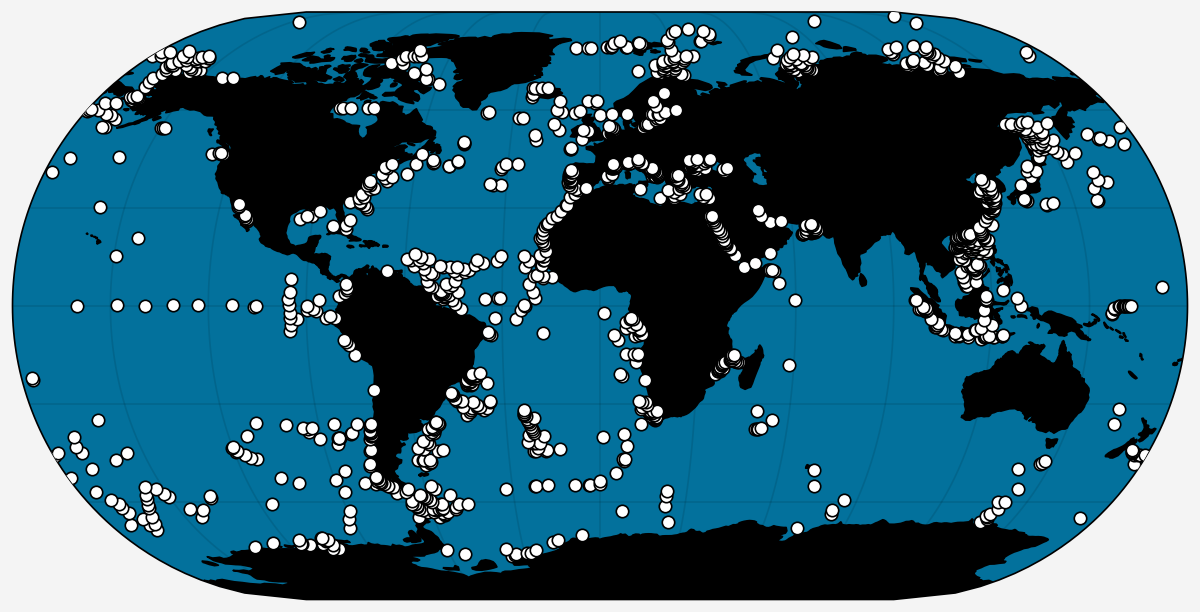

In [14]:
fig, ax = plot.subplots(width=6,proj='eck3',
                        # proj_kw={'lon_0':-150}
                        )
ax.format(
    land=True,landzorder=0,
    facecolor='ocean blue',
    # landcolor='gray7',
    coast=True,coastzorder=1,
    lonlines=30,
    latlines=30,
    # lonlabels='b',
    # latlabels='l',
    # title='Coretop locations',
)

plot_lat = coretop_df['match_lat_04deg']
plot_lon = coretop_df['match_lon_04deg']
ax.scatter(plot_lon, plot_lat, s=20, color='w', mec='k', facecolor='none', zorder=5)
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'coretop_locations_woa23_t00_04degC.pdf'),dpi=300,
            transparent=True)

# Posterior plots --- QC

DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3']
figure nrows, ncols: 3, 3


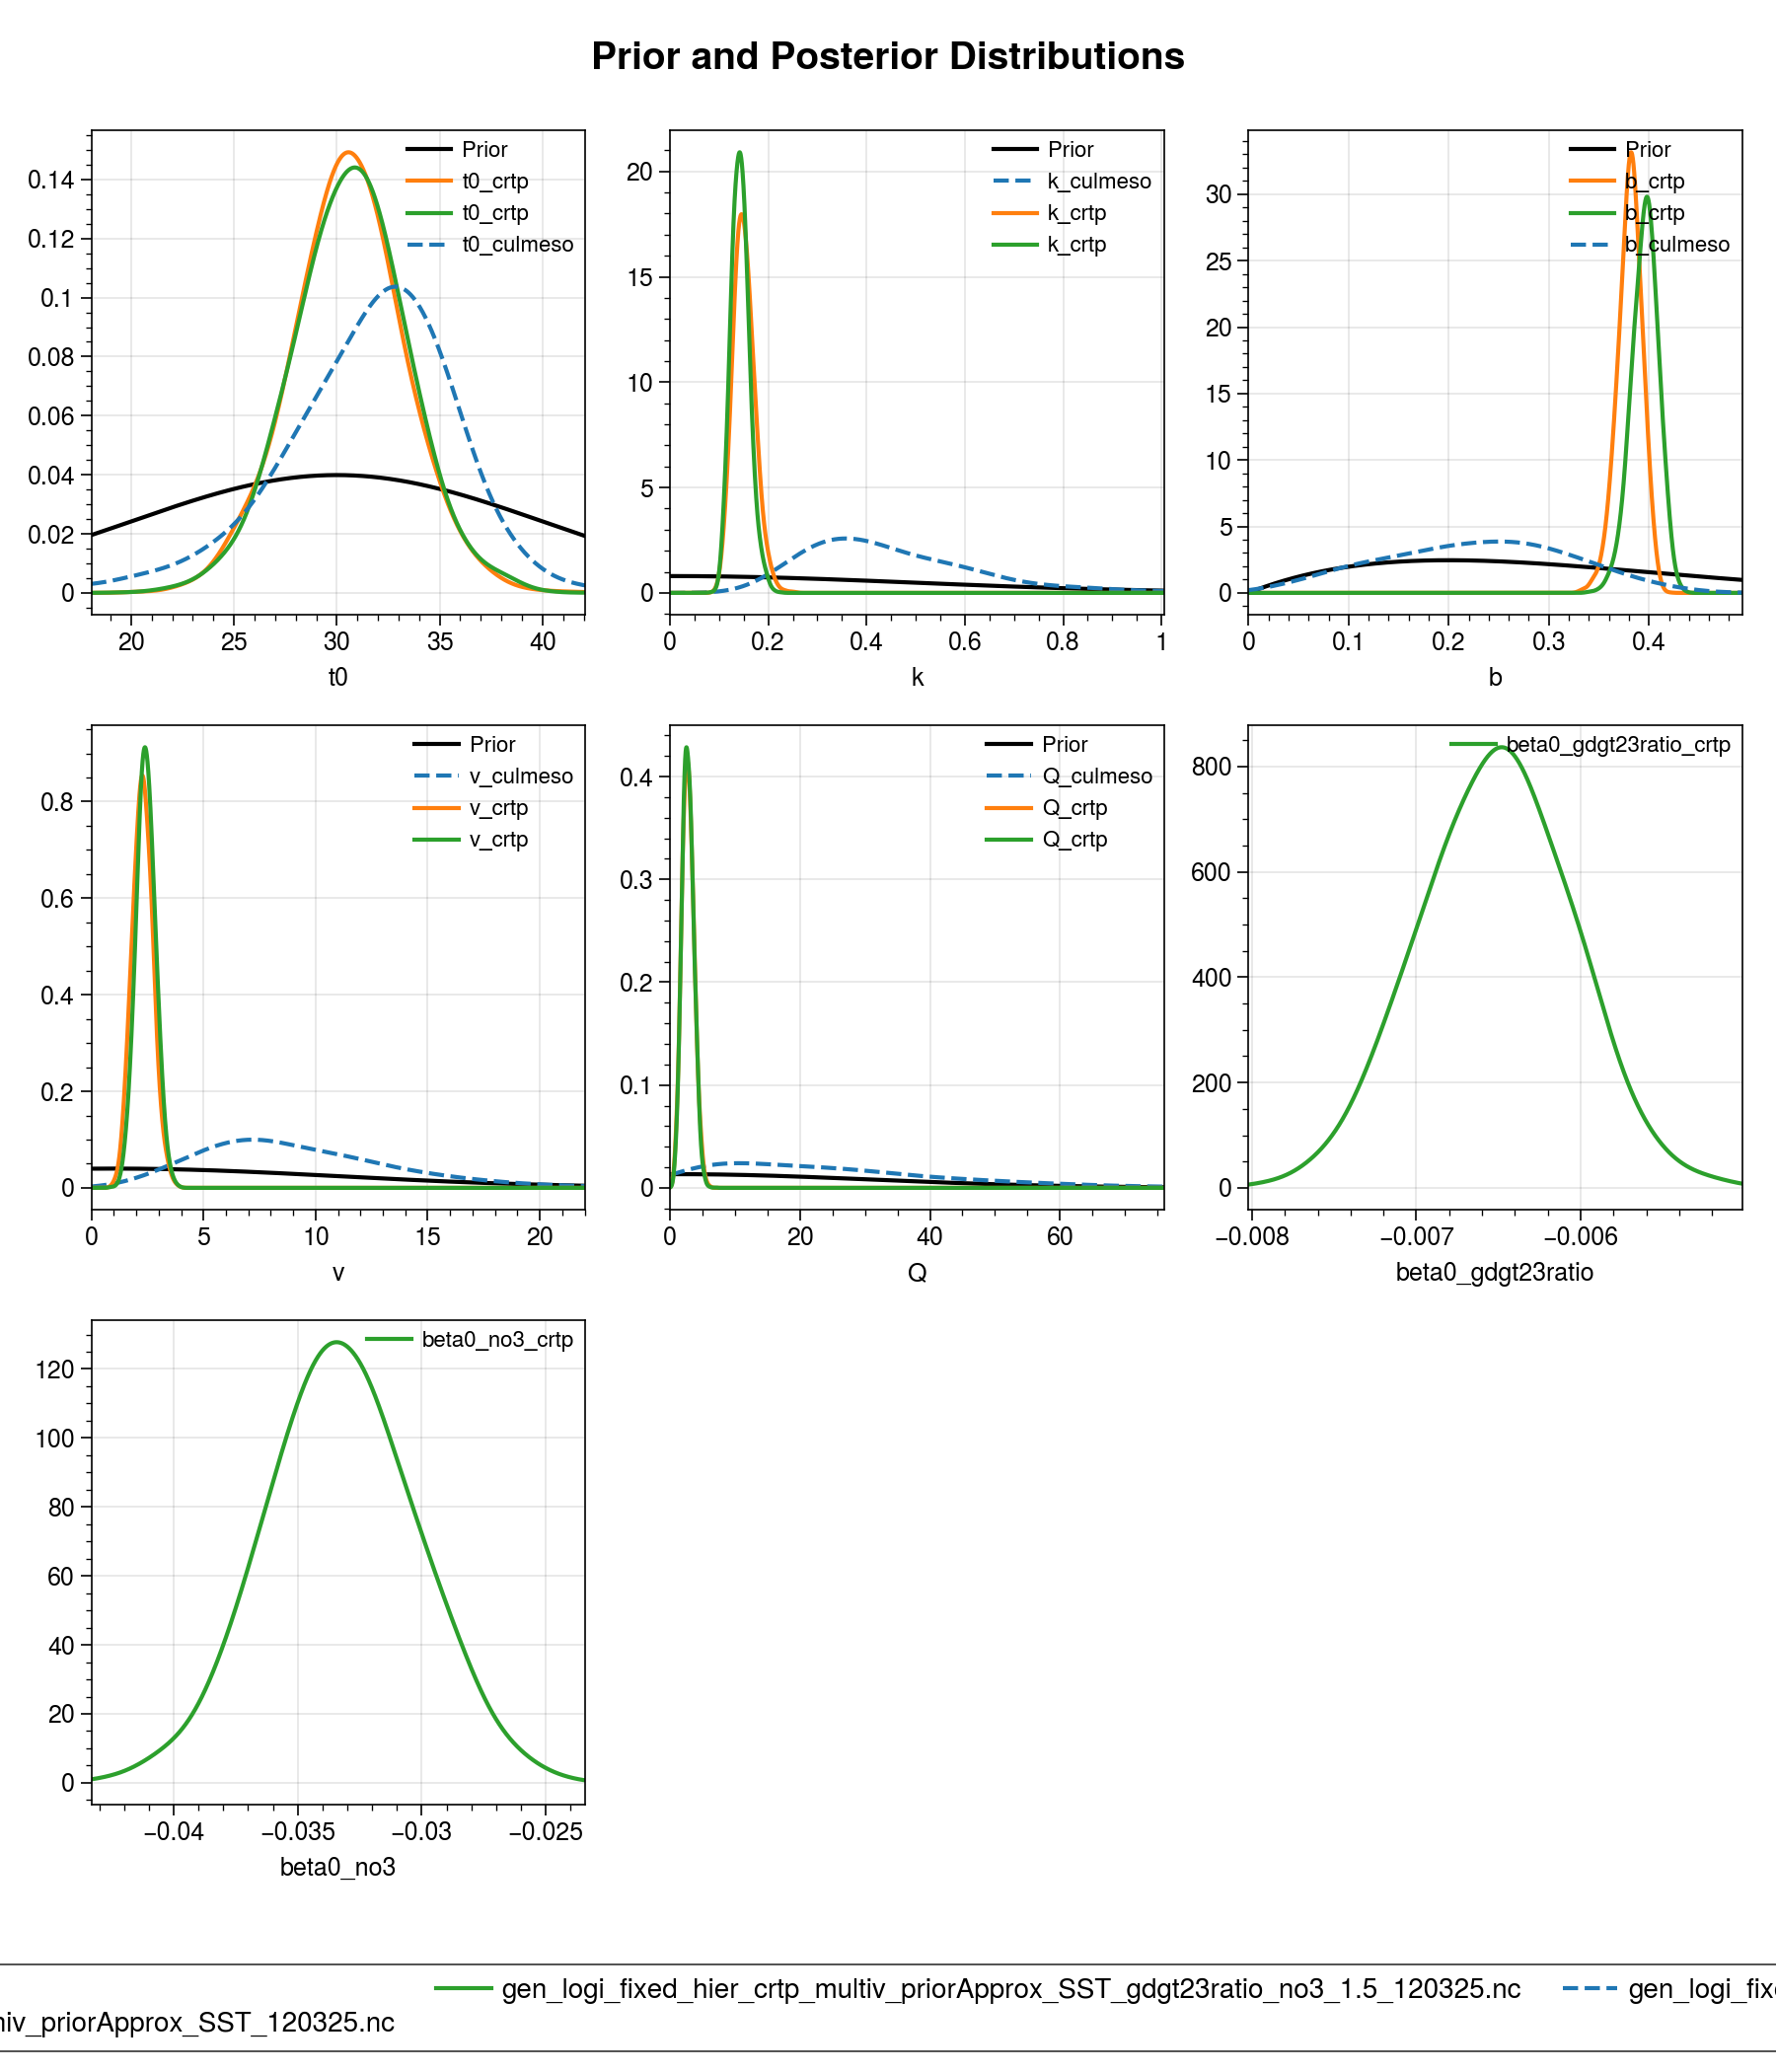

In [15]:
priors = gen_logi_fixed_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[gen_logi_fixed_cul_meso_post_ds,
                        gen_logi_fixed_hier_crtp_univ_priorApprox_post_ds,
                        gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds],
    zoomin_suffix="_crtp",
    use_linestyle_by_param=True,
    show_histogram=False
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'prior_distributions.pdf'),dpi=300)

DEBUG: use_gdgt23ratio detected
DEBUG: use_no3 detected
Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_culmeso', 'Q_crtp'], 'a': [], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'beta0_gdgt23ratio', 'beta0_no3']
figure nrows, ncols: 3, 3


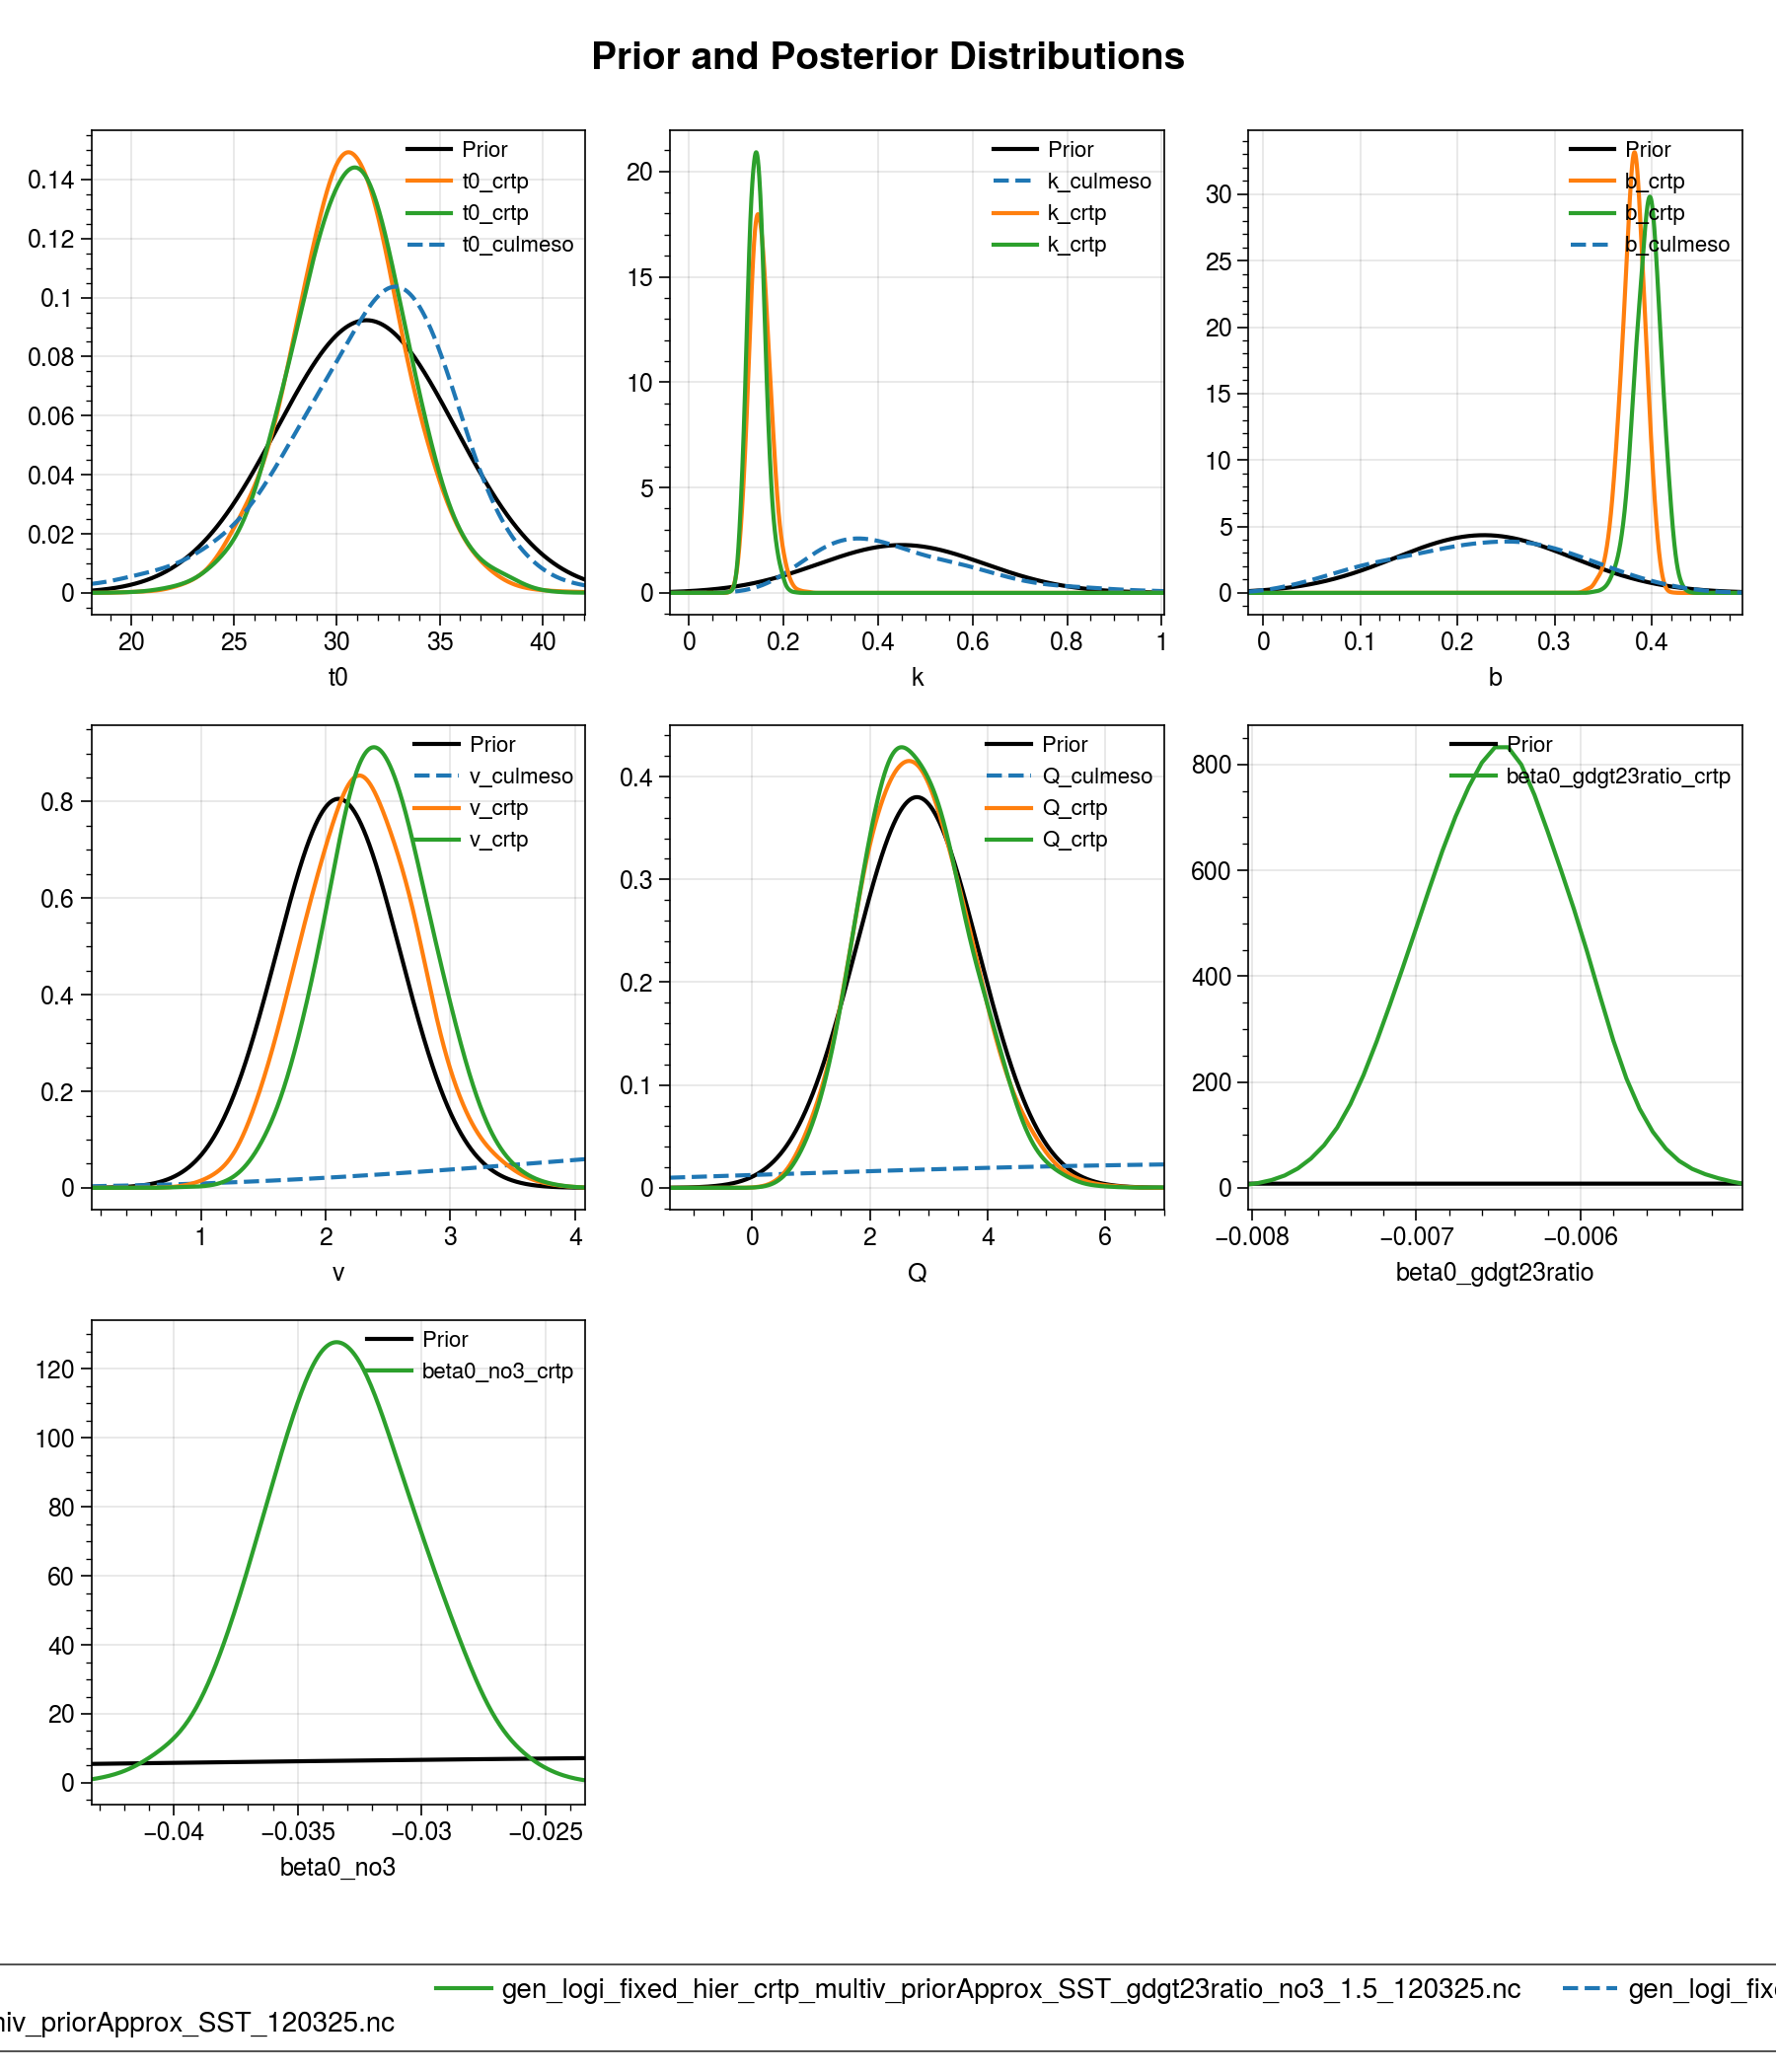

In [16]:
priors = gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[gen_logi_fixed_cul_meso_post_ds,
                        gen_logi_fixed_hier_crtp_univ_priorApprox_post_ds,
                        gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds],
    zoomin_suffix="_crtp",
    use_linestyle_by_param=True,
    show_histogram=False
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want
fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'prior_distributions_multiv.pdf'),dpi=300)

In [17]:
datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

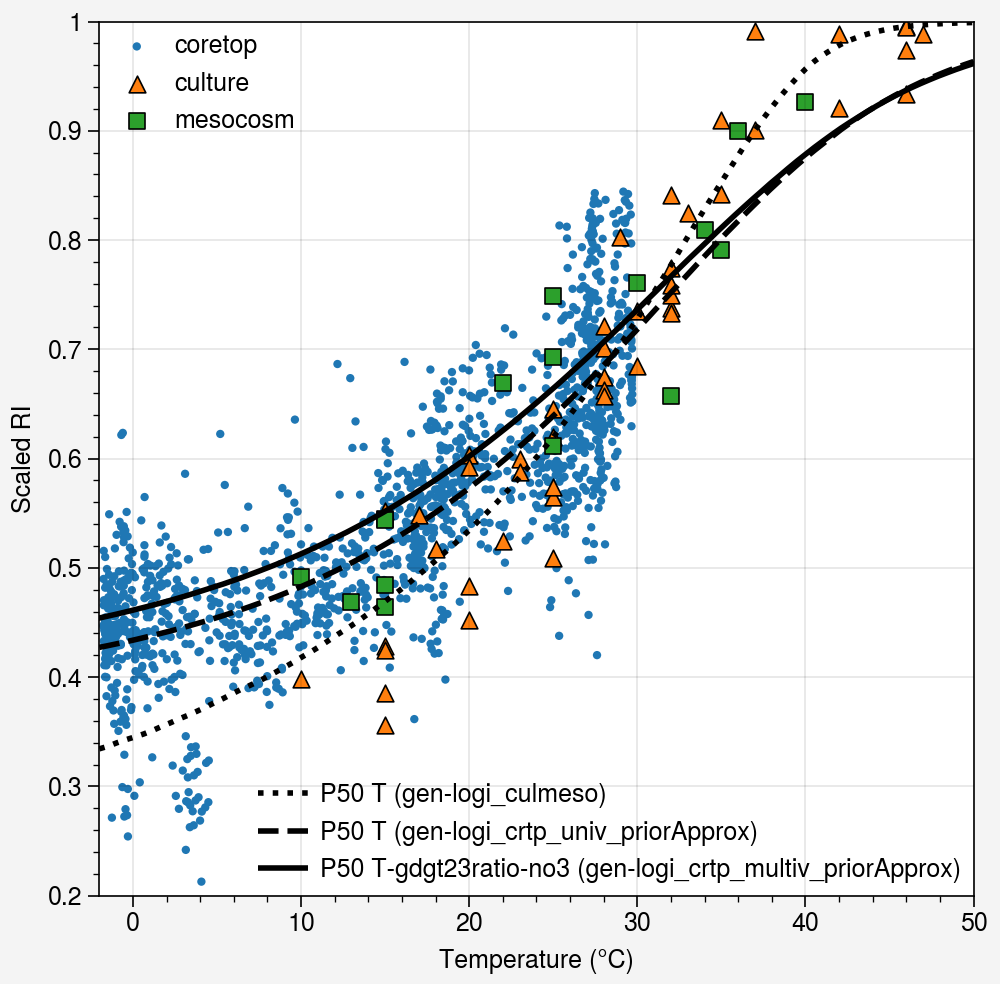

In [18]:
from TEXAS.ensemble import generate_ensemble_auto
fig, ax = plot.subplots(width=5)

grouped = gridded_combined_df.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['SST'], group['scaledRI'], 
               m=datatype_marker_dict.get(name,'o'), 
               mec='none' if name=='coretop' else 'black',
               label=name,
               cycle='tab10')

post_ds_list = [
    gen_logi_fixed_cul_meso_post_ds,
    gen_logi_fixed_hier_crtp_univ_priorApprox_post_ds,
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds
]
ds_labels = [
    'T (gen-logi_culmeso)',
    'T (gen-logi_crtp_univ_priorApprox)',
    'T-gdgt23ratio-no3 (gen-logi_crtp_multiv_priorApprox)',
]
temperature_range = np.linspace(-2, 50, 100)
gdgt23_ratio = np.full(100, 0)  # Constant GDGT-2/3 ratio
no3_vals = np.full(100, 100)  # No NO3 values used
colors = plot.get_colors('tab10',N=len(post_ds_list))
for i, sel_post_ds in enumerate(post_ds_list):
    # Generate ensemble (auto-detection)
    results = generate_ensemble_auto(
        post_ds=sel_post_ds,
        x_vals=temperature_range,
        # gdgt23ratio=gdgt23_ratio,  # Required for multivariate models
        # no3=no3_vals,
        n_draws=500,
        seed=42,
        return_full_ensemble=True
    )
    
    # display(results)

    # Access results
    median_pred = results['p50']        # Median prediction
    lower_bound = results['p5']         # 5th percentile
    upper_bound = results['p95']        # 95th percentile

    ax.plot(temperature_range, median_pred,
            c='k',lw=2,
            ls=[':','--','-'][i],
            label=f'P50 {ds_labels[i]}',)
    # ax.fill_between(temperature_range, lower_bound, upper_bound,
    #                 c=colors[i],alpha=0.2, 
    #                 # label=f'95% CI {sel_post_ds.attrs["filename"]}'
    #                 )

h, l = ax.get_legend_handles_labels()
ax.legend(h[3:], l[3:], loc='ul', ncols=1,frameon=False)
ax.legend(h[:3], l[:3], loc='lr', ncols=1,frameon=False)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Scaled RI')

ax.format(
    ylim=(0.2,1)
)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'scaledRI_vs_T_with_modelFits.pdf'),dpi=300)

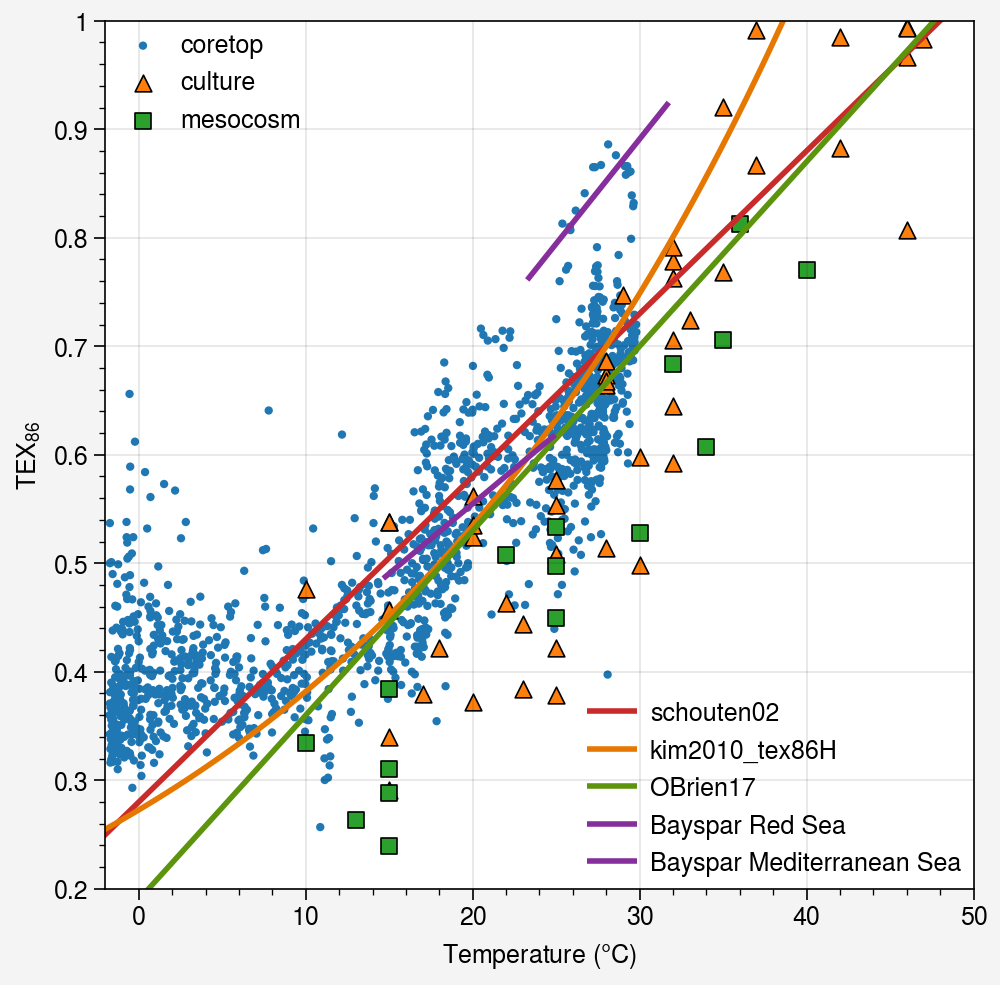

In [19]:
fig, ax = plot.subplots(width=5)

grouped = gridded_combined_df.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['SST'], group['TEX86'], 
               m=datatype_marker_dict.get(name,'o'), 
               mec='none' if name=='coretop' else 'black',
               label=name,
               cycle='tab10')


ax.format(
    xlabel=r'Temperature ($\degree$C)',
    ylabel=r'TEX$_{86}$',
)

#### existing calibration models

temperature_range = np.linspace(-2, 50, 100)
methods = ['schouten02','kim2010_tex86H','OBrien17']
colors = ['red9','yellow9','lime9']
for i, method_name in enumerate(methods):
    predicted_tex = predictTEXfromSST(temperature_range,method_name=method_name)
    ax.plot(temperature_range, predicted_tex,
            c=colors[i],lw=2,
            ls='-',
            label=f'{method_name}',)
    
#### bayspar forward model

mid_redsea_lat = coretop_df[coretop_df['regionName']=='Red Sea']['match_lat_04deg'].median()
mid_redsea_lon = coretop_df[coretop_df['regionName']=='Red Sea']['match_lon_04deg'].median()
min_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].min()-2
max_redsea_sst = coretop_df[coretop_df['regionName']=='Red Sea']['SST'].max()+2

xx = np.linspace(min_redsea_sst, max_redsea_sst, 50)
pred_tex_redsea = bsr.predict_tex(
    xx,
    lat=mid_redsea_lat,
    lon=mid_redsea_lon,
    temptype='sst'
).percentile(50)

ax.plot([xx.min(),xx.max()], [pred_tex_redsea.min(),pred_tex_redsea.max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Red Sea',)


min_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].min()-2
max_mediterranean_sst = coretop_df[coretop_df['regionName']=='Mediterranean']['SST'].max()+2
xx = np.linspace(min_mediterranean_sst, max_mediterranean_sst, 50)

mid_mediterranean_lat = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lat_04deg'].median()
mid_mediterranean_lon = coretop_df[coretop_df['regionName']=='Mediterranean']['match_lon_04deg'].median()
pred_tex_mediterranean = bsr.predict_tex(
    xx,
    lat=mid_mediterranean_lat,
    lon=mid_mediterranean_lon,
    temptype='sst'
).percentile(50)

ax.plot([xx.min(),xx.max()], [pred_tex_mediterranean.min(),pred_tex_mediterranean.max()],
        c='grape9',lw=2,
        ls='-',
        label=f'Bayspar Mediterranean Sea',)

ax.format(
    ylim=(0.2,1)
)

h, l = ax.get_legend_handles_labels()
ax.legend(h[5:], l[5:], loc='ul', ncols=1,frameon=False)
ax.legend(h[:5], l[:5], loc='lr', ncols=1,frameon=False)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'tex86_vs_temp_coretop_and_calibrations.pdf'),dpi=300)

In [20]:
coretop_df[coretop_df['regionName']=='Mediterranean']['match_lat_04deg'].median()

41.375

# Residuals plot

In [21]:
coretop_df

,match_lat_04deg,match_lon_04deg,Strains,datatype,organism_broadClass,organism_commonName,reference_name,regionName,BIT,SST,...,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled,pred_scaledRI,scaledRI_res,pred_scaledRI_23corr,scaledRI_23corr_res
0,-76.625,-35.375,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.008000,-1.42831,...,NaN,NaN,-1.463560,-1.498910,NaN,28.343912,0.433522,-0.000180,0.455107,-0.021765
1,-76.375,-33.875,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.005000,-1.74881,...,NaN,-1.640889,-1.640889,-1.651191,22.066089,22.066089,0.433114,0.014403,0.454853,-0.007335
2,-76.125,-54.125,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.028000,-1.47321,...,-1.578755,NaN,NaN,-1.511355,NaN,NaN,0.433489,0.029287,0.455669,0.007107
3,-76.125,-33.625,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.009000,-1.64251,...,NaN,-1.700194,-1.700194,-1.666310,22.080111,22.080111,0.433074,0.007839,0.454852,-0.013939
4,-75.875,-29.125,coretop,coretop,coretop,coretop,Lamping2021,Weddell Sea,0.009000,-1.65391,...,NaN,NaN,NaN,-1.714410,NaN,NaN,0.432946,0.017749,0.457034,-0.006339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1418,84.875,40.625,coretop,coretop,coretop,coretop,Kim2008,Arctic Ocean,0.581111,-1.64041,...,-1.728518,-1.656510,-1.656510,-1.373924,4.118705,4.118705,0.433861,0.005525,0.445581,-0.006195
1419,86.625,152.125,coretop,coretop,coretop,coretop,Ho2014,Arctic Ocean,NaN,-1.57041,...,-1.610191,-1.572555,-1.572555,-1.156047,0.604361,0.604361,0.434459,-0.051859,0.341515,0.041085
1420,86.875,-146.125,coretop,coretop,coretop,coretop,Ho2014,Arctic Ocean,NaN,-1.56751,...,-1.606820,-1.572210,-1.572210,-1.474355,0.480216,0.480216,0.433589,-0.033739,0.410515,-0.010665
1421,87.125,104.625,coretop,coretop,coretop,coretop,Ho2014,Arctic Ocean,NaN,-1.73371,...,-1.758133,0.133586,0.133586,-1.377392,8.072274,8.072274,0.433851,-0.000776,0.450642,-0.017567


In [24]:
pred_TEX_BAYSPAR = np.full(len(coretop_df), np.nan)
for i, row in tqdm(coretop_df.iterrows()):
    sst = row['SST']
    if not np.isnan(sst):
        pred_TEX_BAYSPAR[i] = bsr.predict_tex(
            np.atleast_1d(sst),
            lat=row['match_lat_04deg'],
            lon=row['match_lon_04deg'],
            temptype='sst'
        ).percentile(50)[0]
        
pred_TEX_BAYSPAR
        

1423it [00:43, 32.73it/s]


array([0.37146494, 0.36971671, 0.37190073, ..., 0.2855807 , 0.26443621,
       0.27625497])

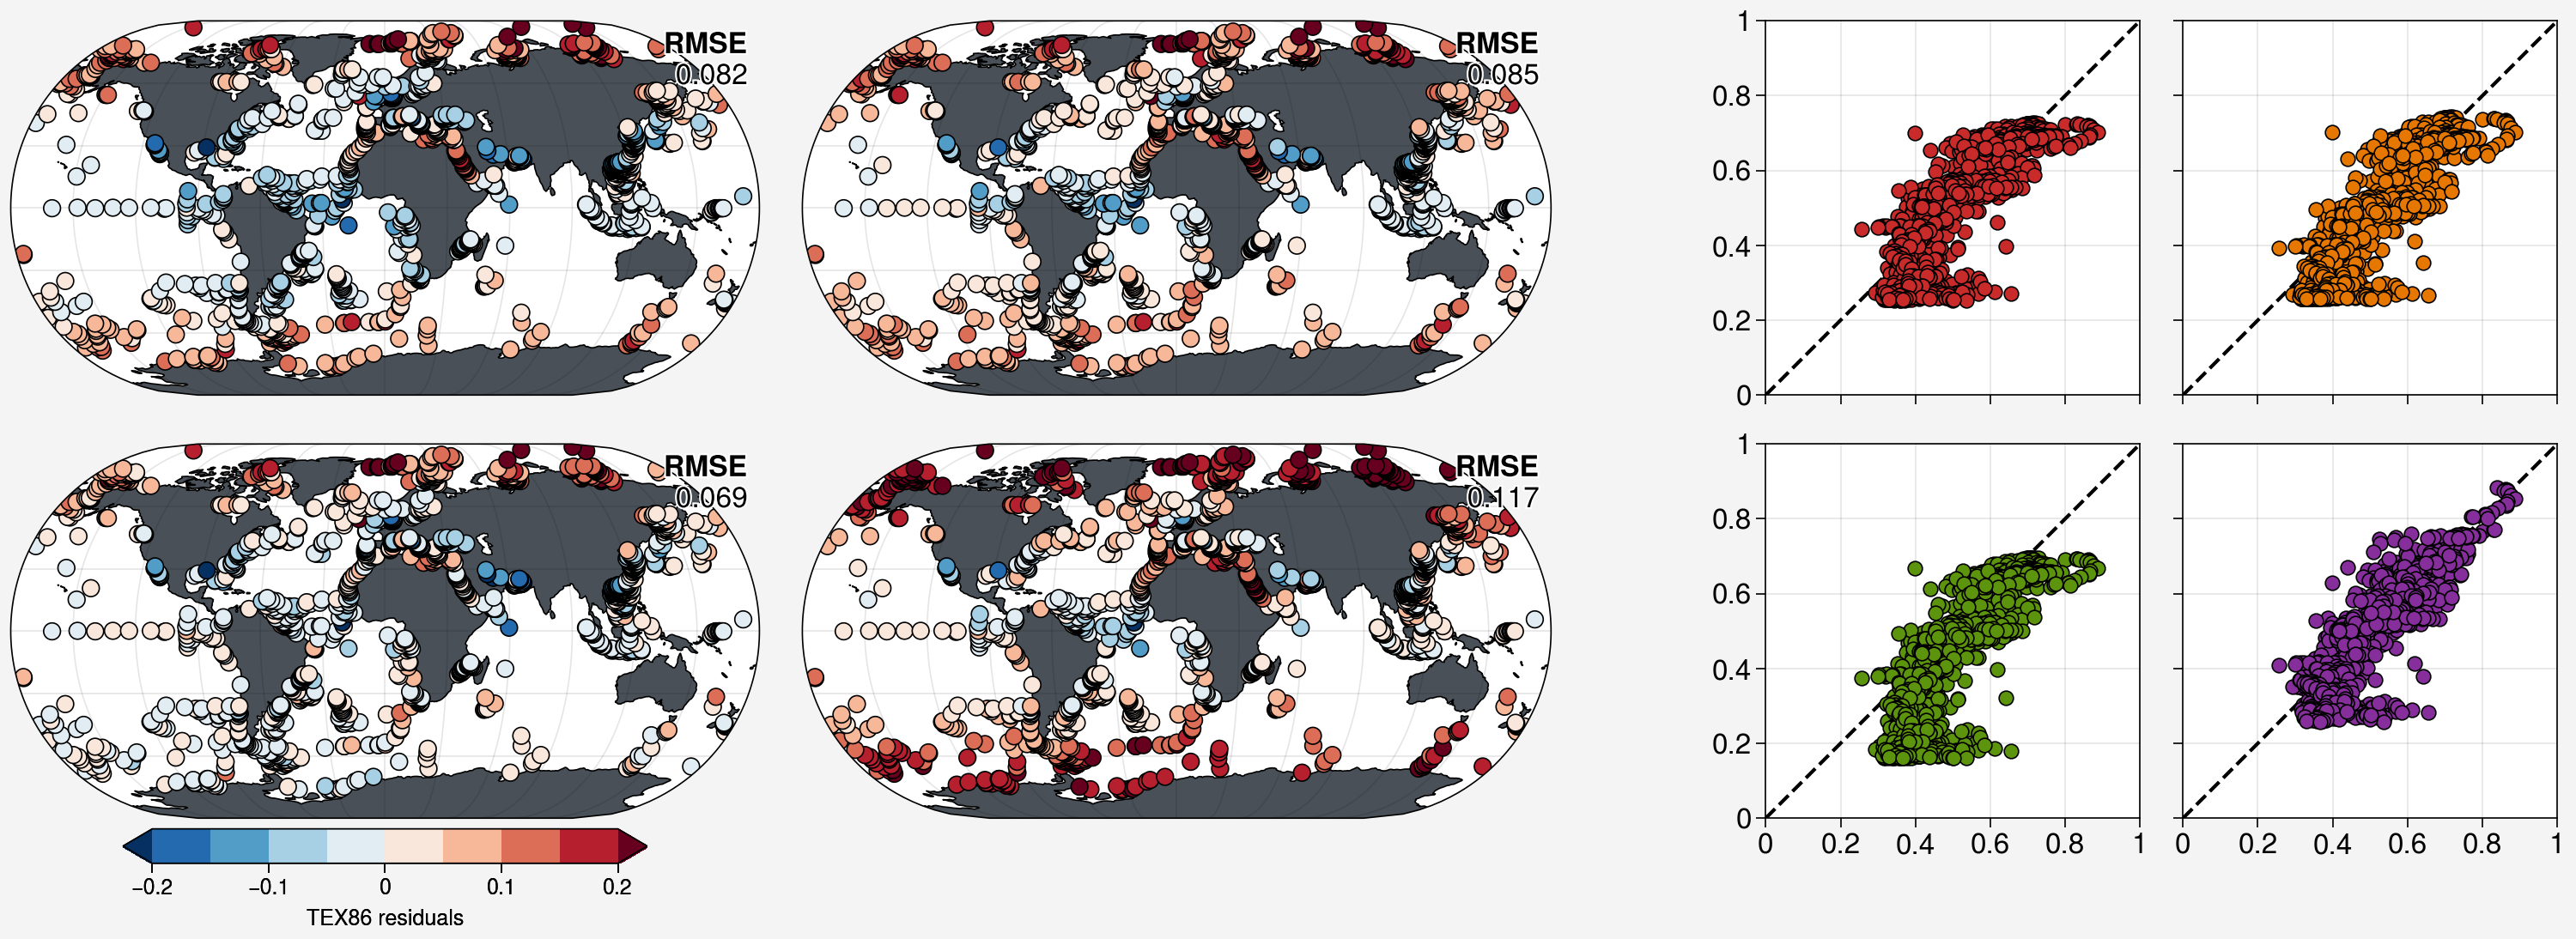

In [25]:
fig, axs = plot.subplots(proj={1:'eck3',2:'eck3',5:'eck3',6:'eck3'},
                         width=15,ncols=4,nrows=2,
                         share=0,
                         wratios=[2,2,1,1],
                         wspace=[2,10,2])

axs.format(
    land=True,landzorder=0,
    landcolor='gray7',
    coast=True,coastzorder=1,
    lonlines=30,
    latlines=30,
    fontsize=12,
)

axs[:,2:].format(tickminor=False)

pred_TEX_schouten02 = predictTEXfromSST(coretop_df['SST'],method_name='schouten02')
pred_TEX_kim2010 = predictTEXfromSST(coretop_df['SST'],method_name='kim2010_tex86H')
pred_TEX_OBrien17 = predictTEXfromSST(coretop_df['SST'],method_name='OBrien17')


TEX_residuals_schouten02 = coretop_df['TEX86'] - pred_TEX_schouten02
TEX_residuals_kim2010 = coretop_df['TEX86'] - pred_TEX_kim2010
TEX_residuals_OBrien17 = coretop_df['TEX86'] - pred_TEX_OBrien17
TEX_residuals_BAYSPAR = coretop_df['TEX86'] - pred_TEX_BAYSPAR

#################################
ax = axs[0,0]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=TEX_residuals_schouten02, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_schouten02 = np.sqrt(np.mean(TEX_residuals_schouten02**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_schouten02:.3f}',
    fontsize=11
)
#################################
ax = axs[0,2]
plot_x = coretop_df['TEX86']
plot_y = pred_TEX_schouten02
ax.scatter(plot_x, plot_y, m='o', c='red9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)



########################################################################
ax = axs[0,1]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=TEX_residuals_kim2010, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_kim2010 = np.sqrt(np.mean(TEX_residuals_kim2010**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_kim2010:.3f}',
    fontsize=11
)
#################################
ax = axs[0,3]
plot_x = coretop_df['TEX86']
plot_y = pred_TEX_kim2010
ax.scatter(plot_x, plot_y, m='o', c='yellow9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)


########################################################################
ax = axs[1,0]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=TEX_residuals_BAYSPAR, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_BAYSPAR = np.sqrt(np.mean(TEX_residuals_BAYSPAR**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_BAYSPAR:.3f}',
    fontsize=11
)
#################################
ax = axs[1,3]
plot_x = coretop_df['TEX86']
plot_y = pred_TEX_BAYSPAR
ax.scatter(plot_x, plot_y, m='o', c='grape9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)



########################################################################
ax = axs[1,1]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=TEX_residuals_OBrien17, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_OBrien17 = np.sqrt(np.mean(TEX_residuals_OBrien17**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_OBrien17:.3f}',
    fontsize=11
)
#################################
ax = axs[1,2]
plot_x = coretop_df['TEX86']
plot_y = pred_TEX_OBrien17
ax.scatter(plot_x, plot_y, m='o', c='lime9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)


########################################################################
axs[-1,0].colorbar(sc, loc='b', label='TEX86 residuals', extend='both',shrink=0.7)

axs[:,2:].format(
    ylabel='',
    xlabel='',
    xlim=(0,1),
    ylim=(0,1),
)

axs[:,-1].format(yticklabels=[])
axs[0,:].format(xticklabels=[])

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'tex86_residuals_maps_and_scatterplots.png'),dpi=300)


In [26]:
predRI_Tonly = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_120325"),
    x_vals = coretop_df['SST'])['p50']

RIres_Tonly = coretop_df['scaledRI'] - predRI_Tonly

In [27]:
pred_RI_T_g23r = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_120325"),
    x_vals = coretop_df['SST'],
    gdgt23ratio = coretop_df['gdgt23ratio'],
)['p50']
RIres_T_g23r = coretop_df['scaledRI'] - pred_RI_T_g23r

In [28]:
predRI_T_g23r_no3 = generate_ensemble_auto(
    load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_120325"),
    x_vals = coretop_df['SST'],
    gdgt23ratio = coretop_df['gdgt23ratio'],
    no3 = coretop_df['no3_sf2tc_avg'],)['p50']
RIres_T_g23r_no3 = coretop_df['scaledRI'] - predRI_T_g23r_no3

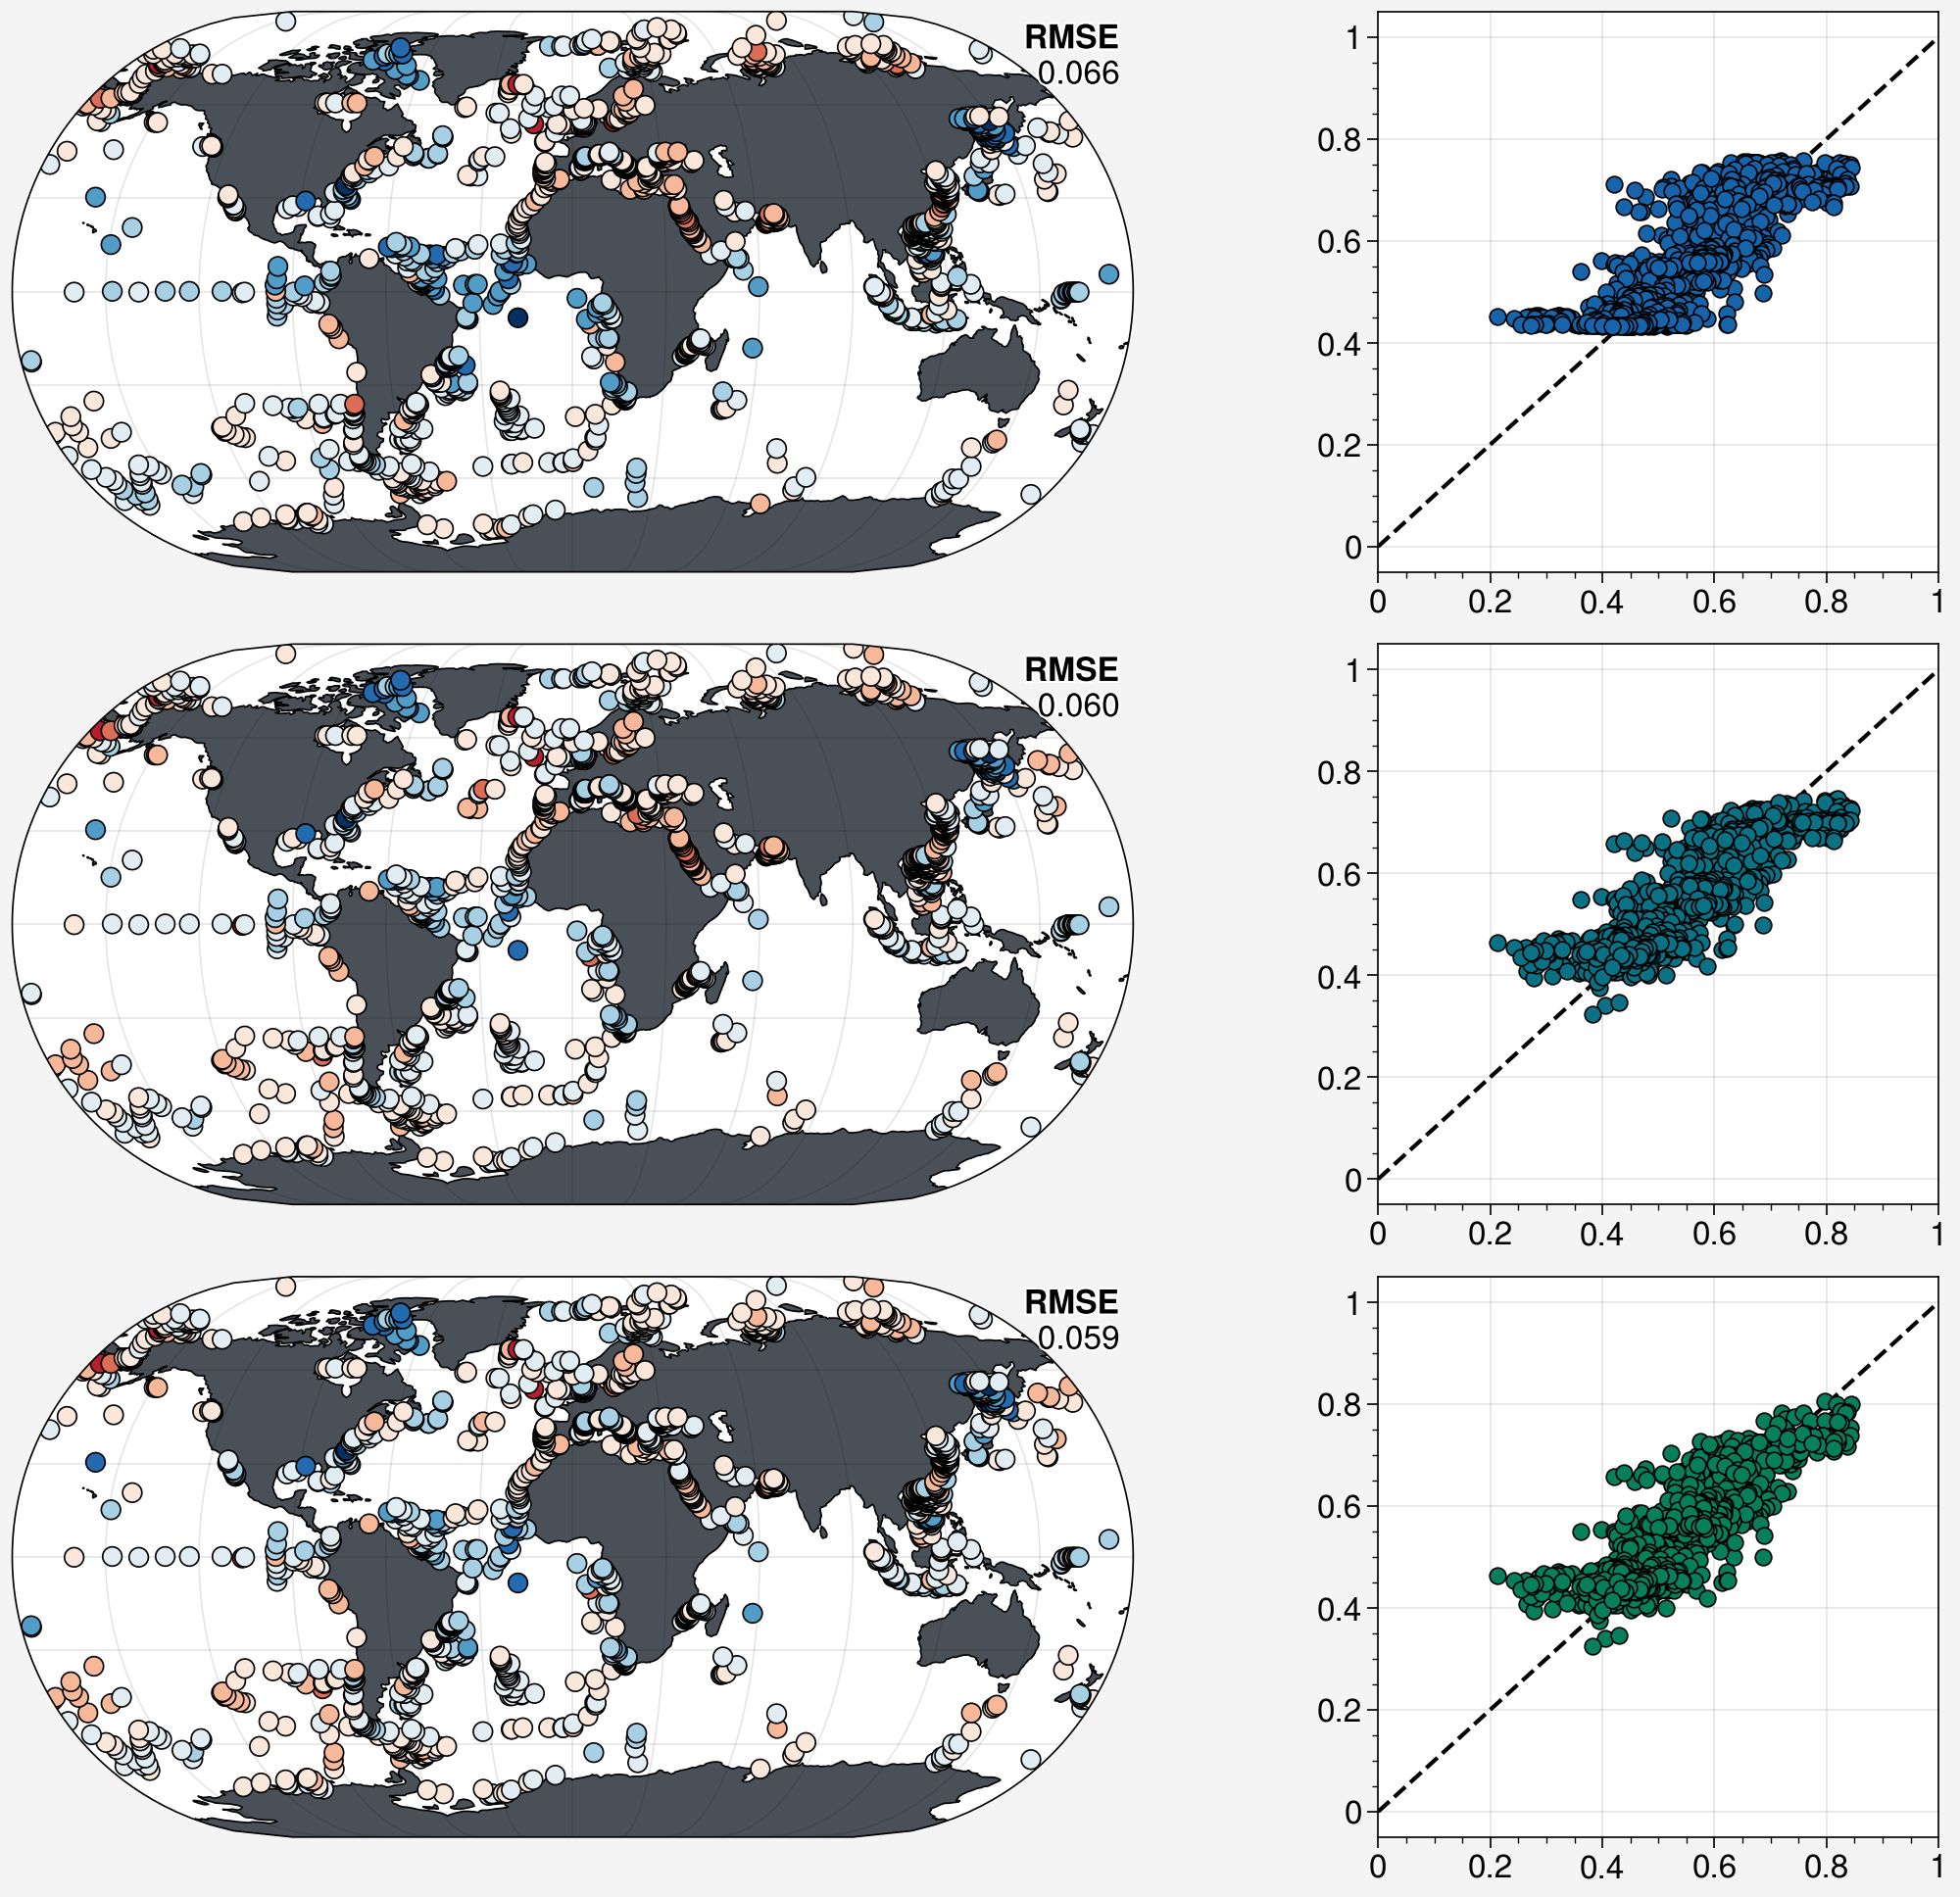

In [29]:
fig, axs = plot.subplots(proj={1:'eck3',3:'eck3',5:'eck3'},
                         width=10,ncols=2,
                         nrows=3,
                         share=0,
                         wratios=[2,1],
                         wspace=10)

axs.format(
    land=True,landzorder=0,
    landcolor='gray7',
    coast=True,coastzorder=1,
    lonlines=30,
    latlines=30,
    fontsize=12,
)

ax = axs[0]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=RIres_Tonly, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_RI_Tonly = np.sqrt(np.mean(RIres_Tonly**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_RI_Tonly:.3f}',
    fontsize=11
)
#################################
ax = axs[1]
plot_x = coretop_df['scaledRI']
plot_y = predRI_Tonly
ax.scatter(plot_x, plot_y, m='o', c='blue9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)

########################################################################
ax = axs[2]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=RIres_T_g23r, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_RI_T_g23r = np.sqrt(np.mean(RIres_T_g23r**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_RI_T_g23r:.3f}',
    fontsize=11
)
#################################
ax = axs[3]
plot_x = coretop_df['scaledRI']
plot_y = pred_RI_T_g23r
ax.scatter(plot_x, plot_y, m='o', c='cyan9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)

########################################################################
ax = axs[4]
sc = ax.scatter(coretop_df['match_lon_04deg'], coretop_df['match_lat_04deg'], 
                c=RIres_T_g23r_no3, 
                cmap='RdBu_r', levels=np.arange(-0.2,0.21,0.05),
                extend='both',
                s=50,mec='k',
                zorder=2
                )
RMSE_RI_T_g23r_no3 = np.sqrt(np.mean(RIres_T_g23r_no3**2))
ax.format(
    urtitle=r'$\mathbf{RMSE}$'+f'\n{RMSE_RI_T_g23r_no3:.3f}',
    fontsize=11
)
#################################
ax = axs[5]
plot_x = coretop_df['scaledRI']
plot_y = predRI_T_g23r_no3
ax.scatter(plot_x, plot_y, m='o', c='teal9',mec='k', zorder=2)
ax.plot([0,1],[0,1],c='k',ls='--',zorder=0)

fpath = f'{local_onedrive_path}/Postdoc/Workshops and Conferences/2025/AGU 2025/poster/figures'
fig.savefig(os.path.join(fpath,'scaledRI_residuals_maps_and_scatterplots.png'),dpi=300)

# PhanTEX Analysis

In [30]:
# Paleo-data plotting
fpath = fr'{local_github_path}/data/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pubYear
0,NaN,DEQ161-592,NaN,19.13,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
1,NaN,DEQ161-592,NaN,20.56,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
2,NaN,DEQ161-592,NaN,20.97,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
3,NaN,DEQ161-592,NaN,21.78,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
4,NaN,DEQ161-592,NaN,22.09,NaN,NaN,Yorktown,United States of America,na,36.68,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35355,NaN,SdrVdium,NaN,244.50,214.5,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35356,NaN,SdrVdium,NaN,260.50,230.5,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35357,NaN,SdrVdium,NaN,268.40,238.4,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020
35358,NaN,SdrVdium,NaN,284.80,254.8,NaN,NaN,NaN,at,55.15,...,NaN,NaN,NaN,NaN,NaN,Herbert,2020,https://doi.org/10.1029/2020PA003935,NaN,Herbert2020


In [31]:
# PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
# PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
#                                         'GDGT0':'fGDGT_0',
#                                         'GDGT1':'fGDGT_1',
#                                         'GDGT2':'fGDGT_2',
#                                         'GDGT3':'fGDGT_3',
#                                         'Cren':'fGDGT_cren',
#                                         'Crenisomer':'fGDGT_cren_prime'})
# PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)

# features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
# sum_allGDGTs = PhanTEX_df[features].sum(axis=1)
# for feat in features:
#     PhanTEX_df[feat] = PhanTEX_df[feat] / sum_allGDGTs
# PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_zhang16.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
# PhanTEX_df['ringIndex'] = numerator / denominator
# PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
# PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

# PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
# PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
# PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
# PhanTEX_df

# # Plate reconstructions

# import pygplates

# rot_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# rot_filename="m06c9h_3id_forPgeog_19o_r1c.rot"
# rotation_model = pygplates.RotationModel(rot_filepath+rot_filename)

# poly_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# statPoly_filename="PALEOMAP_PlatePolygons__forPgeog_v19o.gpml"
# static_polygons = pygplates.FeatureCollection(poly_filepath+statPoly_filename)

# from tqdm import tqdm

# start_time = time.time()

# PhanTEX_df['paleolat'] = np.nan
# PhanTEX_df['paleolon'] = np.nan

# for i in tqdm(range(len(PhanTEX_df.ModLat))):
#     if np.isnan(PhanTEX_df.Age.iloc[i]):
#         continue
#     else:
#         point = pygplates.PointOnSphere(float(PhanTEX_df.ModLat.iloc[i]),float(PhanTEX_df.ModLon.iloc[i]))
#         point_feature = pygplates.Feature()
#         point_feature.set_geometry(point)

#         #Assign a point into an associated plate based on modern-day location, rotation files, etc.
#         partitioned_point_features = pygplates.partition_into_plates(static_polygons,
#                                                                 rotation_model,
#                                                                 point_feature) 



#         # Reconstruct the points to Age
#         reconstructed_point_features = []
#         pygplates.reconstruct(partitioned_point_features,
#                                 rotation_model,
#                                 reconstructed_point_features,
#                                 PhanTEX_df.Age.iloc[i])

#         point = reconstructed_point_features[0].get_reconstructed_geometry()
#         latitude, longitude = point.to_lat_lon()

#         PhanTEX_df.paleolat.iloc[i] = np.round(latitude,decimals=5)
#         PhanTEX_df.paleolon.iloc[i] = np.round(longitude,decimals=5)sum_allGDGTs = 


# print("%.4f seconds" % (time.time() - start_time))
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_df.to_csv(os.path.join(fpath,'PhanTEX_v001_modified_120325.csv'),index=False)

In [32]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanTEX_v001_modified_120325.csv'
PhanTEX_df = pd.read_csv(os.path.join(fpath,fname))

In [33]:
PhanTEX_df.columns

Index(['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth',
       'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age',
       'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'TEX86',
       'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2',
       'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn',
       'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c',
       'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'fGDGT_0',
       'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',
       'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI',
       'pubYear', 'ringIndex', 'scaledRI', 'gdgt23ratio', 'thermoT_linear',
       'SST_Schouten02', 'SST_Kim10', 'paleolat', 'paleolon',
       'mahalanobis_distance'],
      dtype='object')

In [34]:
import numpy as np
from scipy.linalg import inv

class MahalanobisDistance:
    def __init__(self):
        self.mean_ = None
        self.cov_inv_ = None
    
    def fit(self, X):
        """Fit the model on reference data"""
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        self.cov_inv_ = inv(cov)
        return self
    
    def distance(self, X):
        """Compute Mahalanobis distance for new data"""
        diff = X - self.mean_
        distances = np.sqrt(np.sum(diff @ self.cov_inv_ * diff, axis=1))
        return distances

X_train = gridded_combined_df[['ringIndex','TEX86']].dropna().to_numpy()
# Usage
md_model = MahalanobisDistance()
md_model.fit(X_train)  # Fit on Dataset 1

# Apply to Dataset 2
X_test = PhanTEX_df[['ringIndex','TEX86']].dropna().to_numpy()
distances = md_model.distance(X_test)
print("Distances:", distances)

### add distances to PhanTEX_df
PhanTEX_df['mahalanobis_distance'] = np.nan
PhanTEX_df.loc[PhanTEX_df[['ringIndex','TEX86']].dropna().index, 'mahalanobis_distance'] = distances
PhanTEX_df['outliers'] = ((PhanTEX_df['mahalanobis_distance']>3.0349) & ~((PhanTEX_df['ringIndex']>3.5)&(PhanTEX_df['TEX86']>0.6)))
PhanTEX_df

Distances: [1.42780764 1.68685639 1.42385521 ... 2.26445643 2.21245332 2.1813945 ]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,ringIndex,scaledRI,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,paleolat,paleolon,mahalanobis_distance,outliers
0,NaN,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.65,...,2.692752,0.673188,2.975410,30.333373,28.061152,28.043613,17.35493,29.48749,1.427808,False
1,NaN,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.65,...,2.676383,0.669096,2.711864,32.086507,29.491964,28.939558,17.34220,29.48924,1.686856,False
2,NaN,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.65,...,2.792211,0.698053,2.599119,30.764599,28.413095,28.266512,17.32728,29.49129,1.423855,False
3,NaN,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.65,...,2.877008,0.719252,3.118881,31.479751,28.996763,28.632522,17.31416,29.49309,1.502408,False
4,NaN,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.65,...,2.626159,0.656540,3.213920,30.576403,28.259500,28.169440,17.30117,29.49487,1.547579,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7849,NaN,Mid-Waipara River,NaN,NaN,NaN,173.75,NaN,New Zealand,au,-43.06,...,3.127375,0.781844,2.472160,36.970684,33.478162,31.301895,-52.42522,-162.12704,2.033900,False
7850,NaN,Mid-Waipara River,NaN,NaN,NaN,170.40,NaN,New Zealand,au,-43.06,...,3.028662,0.757166,2.614379,34.248892,31.256785,30.008682,-52.61069,-162.13945,1.787825,False
7851,NaN,Mid-Waipara River,NaN,NaN,NaN,167.04,NaN,New Zealand,au,-43.06,...,3.270462,0.817615,2.232558,38.763949,34.941727,32.124169,-52.79211,-162.15096,2.264456,False
7852,NaN,Mid-Waipara River,NaN,NaN,NaN,164.81,NaN,New Zealand,au,-43.06,...,3.198866,0.799717,2.287009,38.929990,35.077240,32.199165,-52.91305,-162.15827,2.212453,False


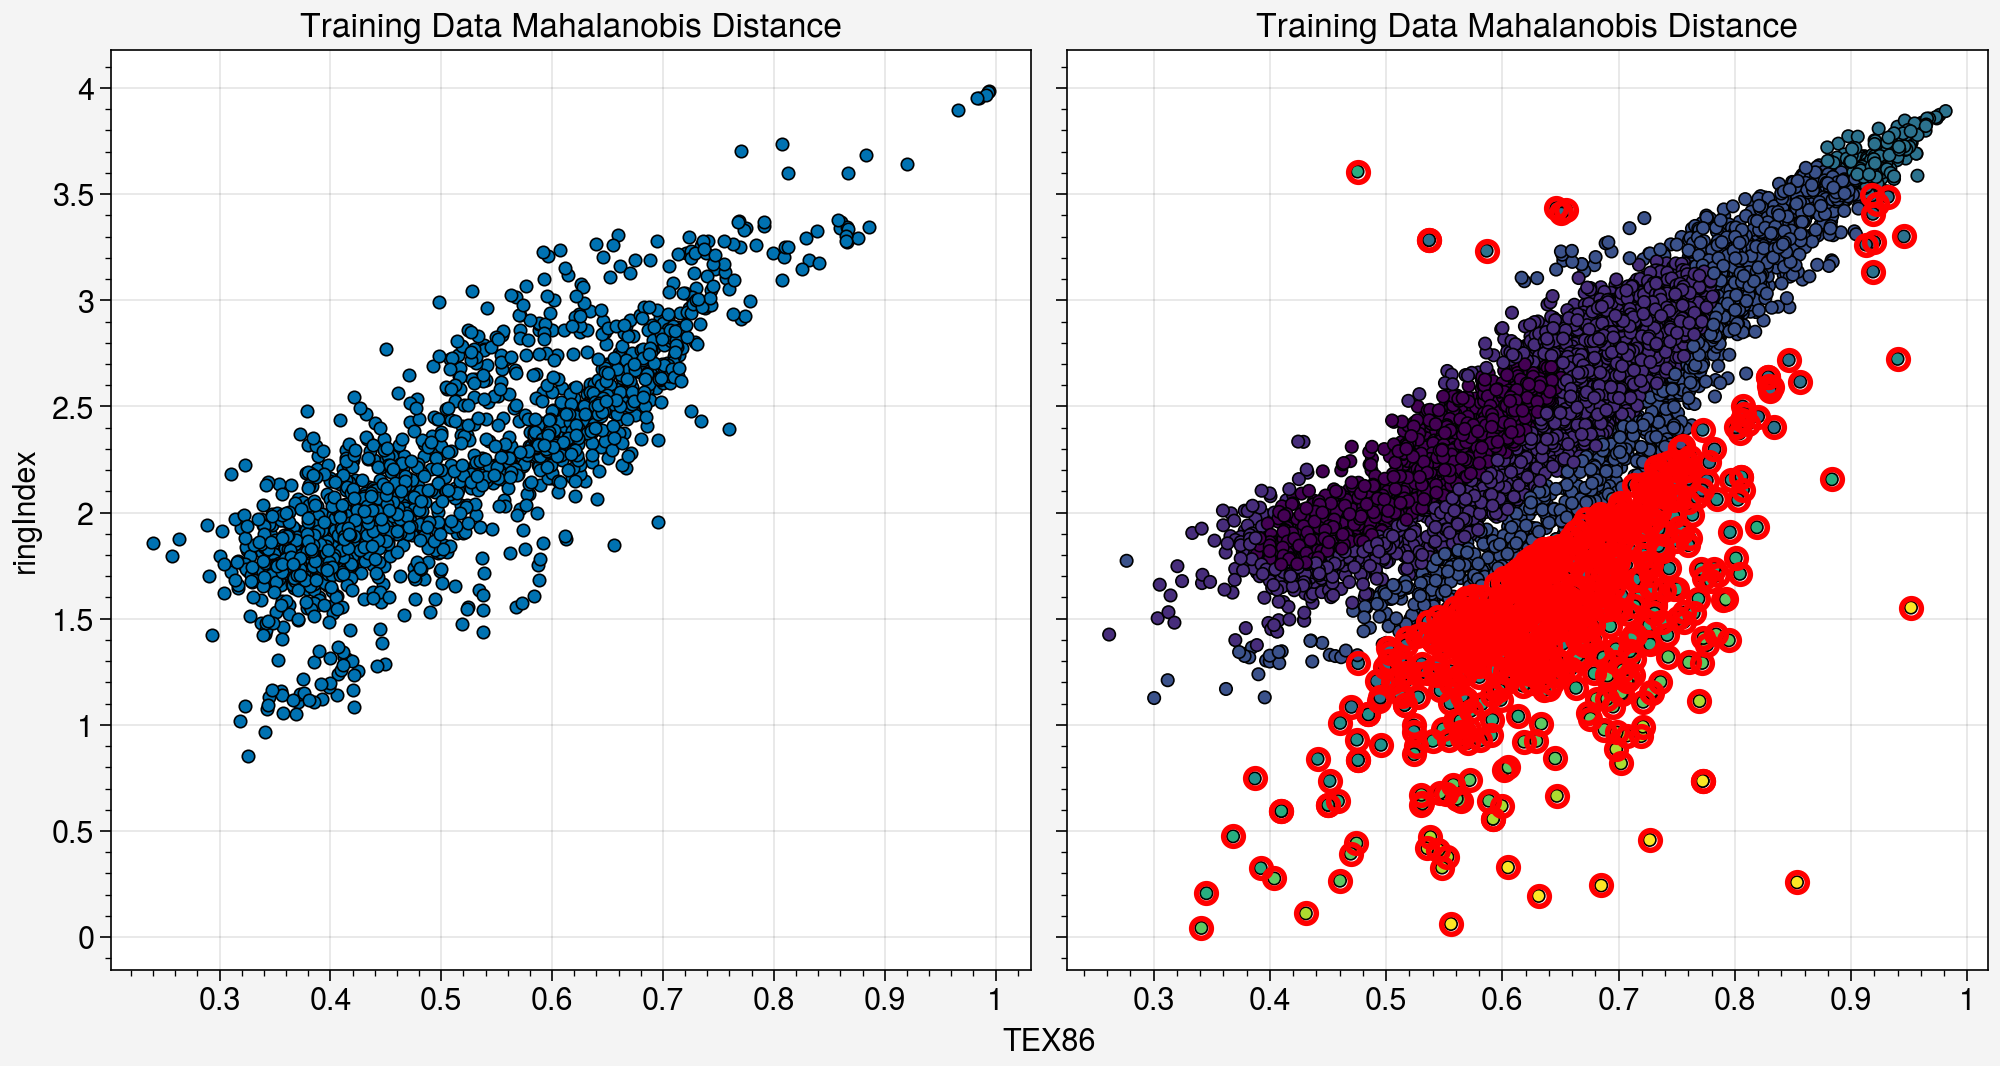

In [35]:
fig, axs = plot.subplots(ncols=2,
                         width=10)

ax = axs[0]
plot_x = gridded_combined_df['TEX86']
plot_y = gridded_combined_df['ringIndex']
sc = ax.scatter(plot_x, plot_y, 
                # c=gridded_combined_df['mahalanobis_distance'],
                cmap='viridis',
                levels=np.arange(0,10,1),
                s=20,mec='k',
                zorder=2
                )
ax.format(
    title='Training Data Mahalanobis Distance',
    fontsize=11
)

ax = axs[1]
plot_x = PhanTEX_df['TEX86']
plot_y = PhanTEX_df['ringIndex']
sc = ax.scatter(plot_x, plot_y, 
                c=PhanTEX_df['mahalanobis_distance'],
                cmap='viridis',
                levels=np.arange(0,10,1),
                s=20,mec='k',
                zorder=2,
                )


outliers = PhanTEX_df[((PhanTEX_df['mahalanobis_distance']>3.0349)
                       & ~((PhanTEX_df['ringIndex']>3.5)&(PhanTEX_df['TEX86']>0.6)))]
ax.scatter(outliers['TEX86'], outliers['ringIndex'], 
           s=50,facecolor='none',edgecolor='red',linewidth=2,
           label='Outliers (D>3.0349)',
           zorder=3)



ax.format(
    title='Training Data Mahalanobis Distance',
    fontsize=11
)

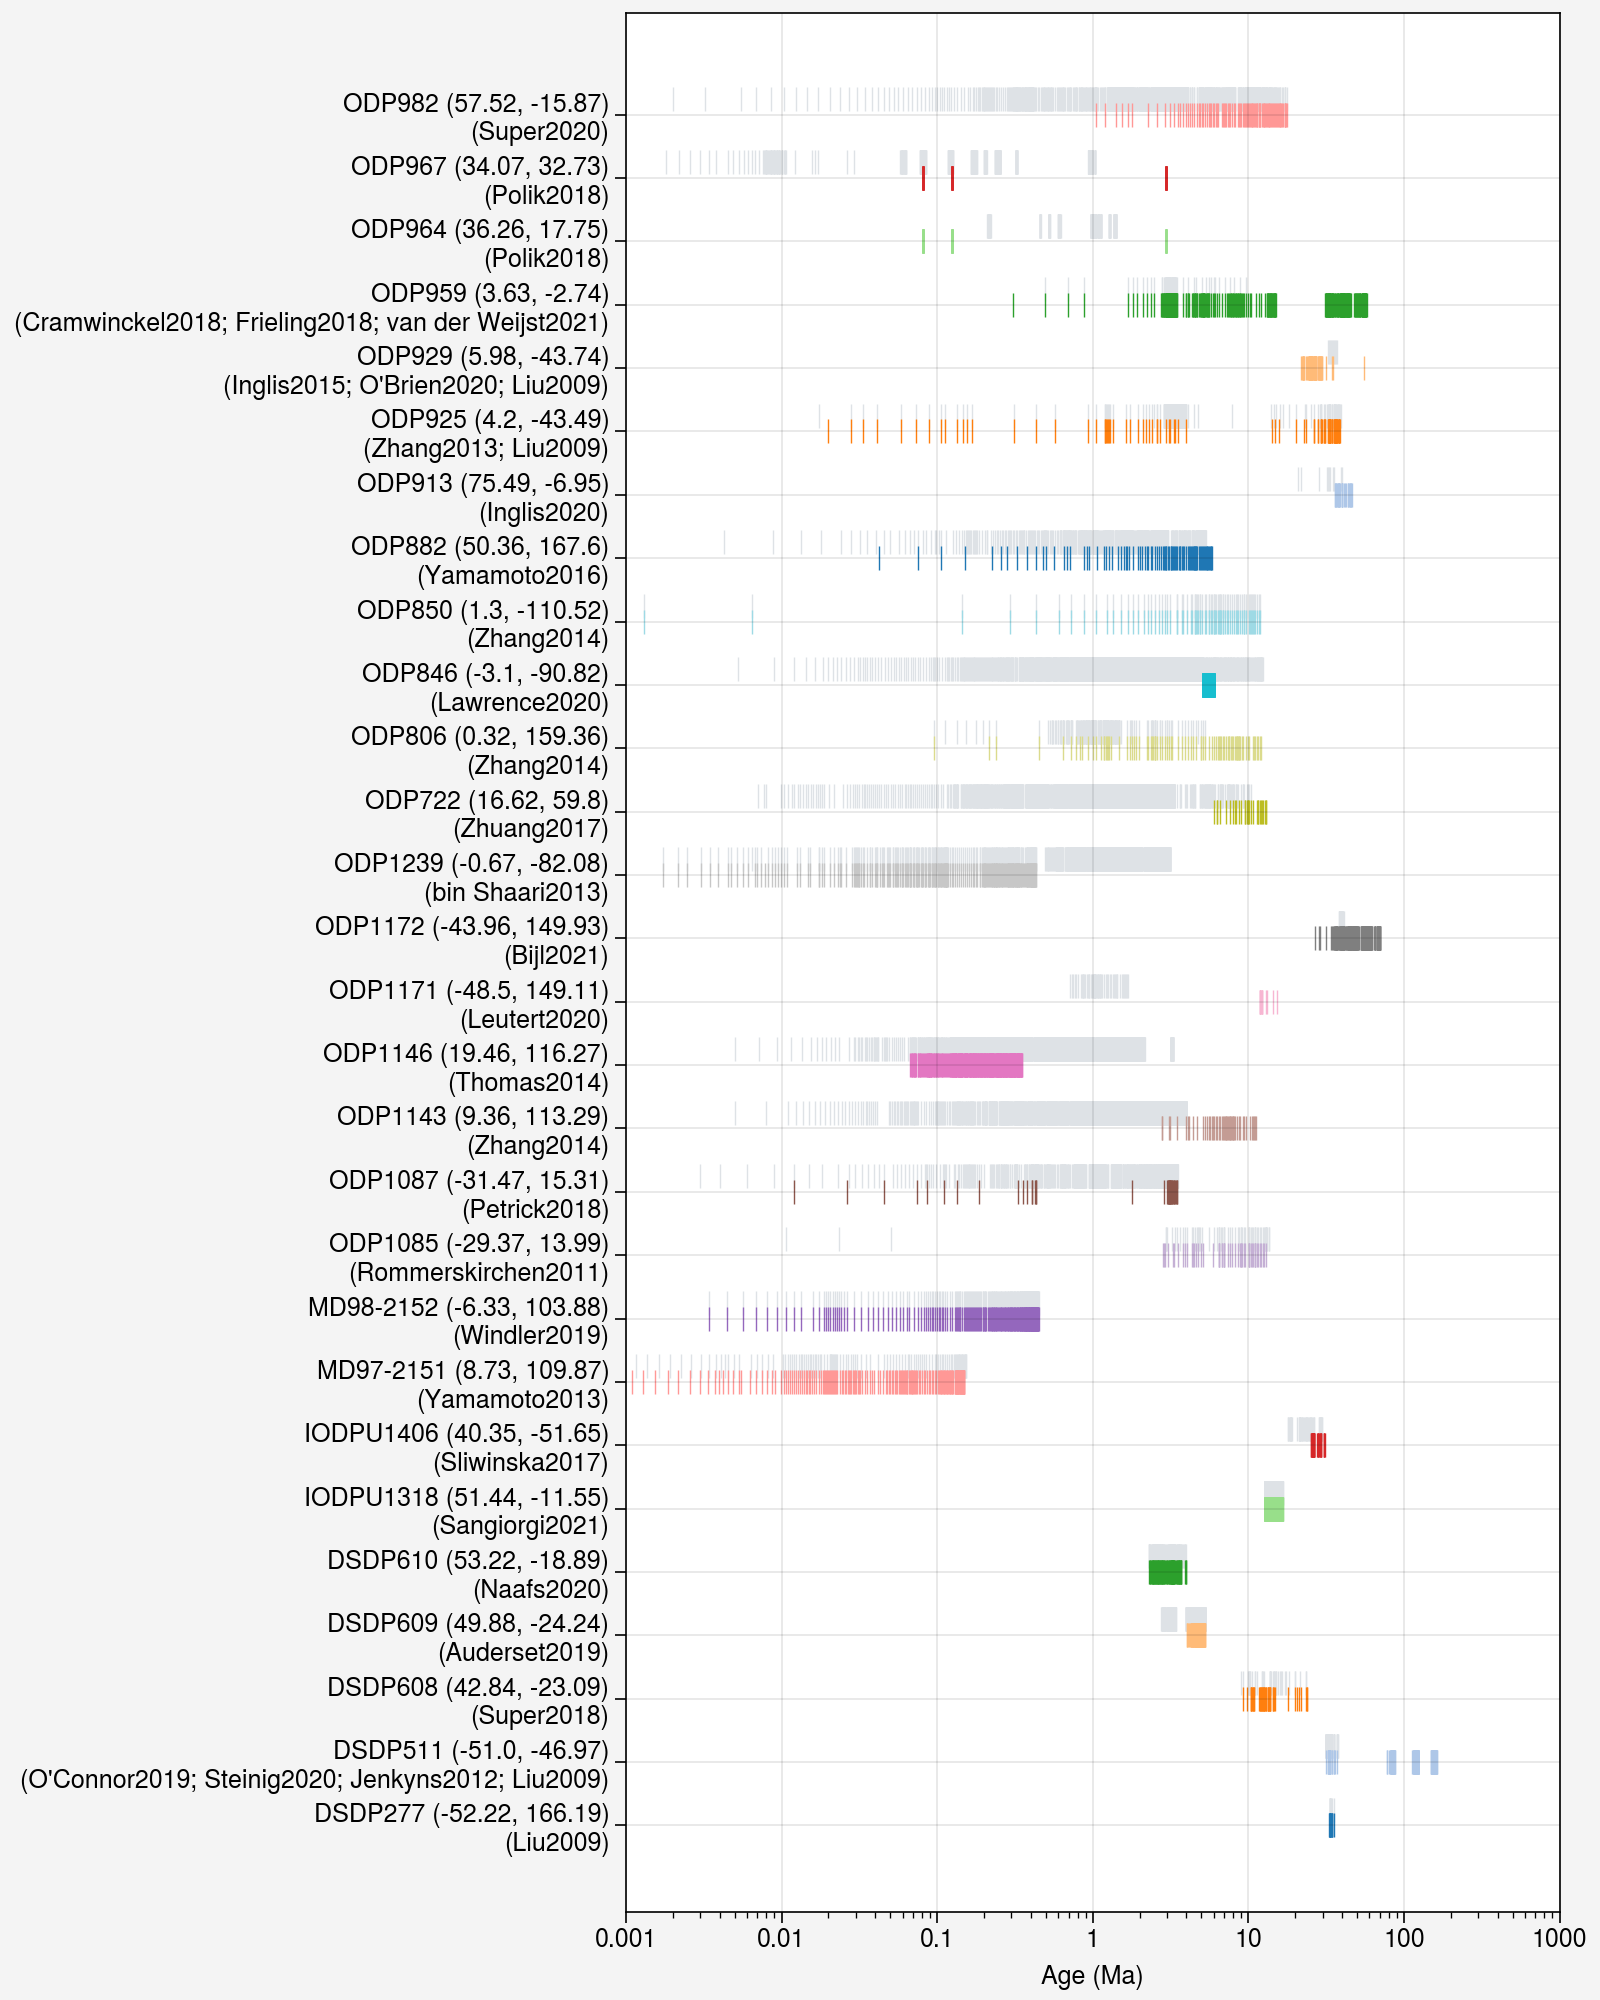

In [36]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['outliers']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=8, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [37]:
import xarray as xr
import xesmf as xe
import numpy as np
import gc
import os
import hashlib

def regrid_curvilinear_to_latlon(
    ds,
    var_names,
    lat_name=None,
    lon_name=None,
    target_res=0.5,
    lat_range=(-90, 90),
    lon_range=(0, 360),
    method='bilinear',
    periodic=True,
    squeeze_dims=None,
    keep_attrs=True,
):
    """
    Regrid data from curvilinear grid to regular lat/lon grid.
    """
    regridder = None
    
    # Create unique weight filename based on grid configuration
    grid_config = f"{method}_{target_res}_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}"
    grid_hash = hashlib.md5(grid_config.encode()).hexdigest()[:8]
    weight_file = f'regrid_weights_{grid_hash}.nc'
    
    try:
        if isinstance(var_names, str):
            var_names = [var_names]
        
        # Auto-detect lat/lon coordinate names
        if lat_name is None or lon_name is None:
            print("Auto-detecting coordinate names...")
            
            lat_candidates = ['TLAT', 'lat', 'latitude', 'LAT', 'Lat']
            lon_candidates = ['TLONG', 'lon', 'longitude', 'LON', 'Lon', 'LONG']
            
            for lat_cand in lat_candidates:
                if lat_cand in ds:
                    lat_name = lat_cand
                    print(f"  Found latitude: {lat_name}")
                    break
            
            for lon_cand in lon_candidates:
                if lon_cand in ds:
                    lon_name = lon_cand
                    print(f"  Found longitude: {lon_name}")
                    break
            
            if lat_name is None or lon_name is None:
                raise ValueError(
                    f"Could not auto-detect coordinates.\n"
                    f"Available variables: {list(ds.variables)}\n"
                    f"Please specify lat_name and lon_name explicitly."
                )
        
        # Get dimensions
        lat_dims = ds[lat_name].dims
        lon_dims = ds[lon_name].dims
        
        if lat_dims != lon_dims:
            raise ValueError(
                f"Latitude and longitude have different dimensions:\n"
                f"  {lat_name}: {lat_dims}\n"
                f"  {lon_name}: {lon_dims}"
            )
        
        if len(lat_dims) != 2:
            raise ValueError(
                f"Expected 2D coordinates, got {len(lat_dims)}D: {lat_dims}"
            )
        
        lat_dim, lon_dim = lat_dims
        print(f"  Dimensions: {lat_dim}, {lon_dim}")
        
        # Get source coordinates
        lat_vals = ds[lat_name].values.copy()
        lon_vals = ds[lon_name].values.copy()
        
        print(f"\nSource coordinates:")
        print(f"  Lat range: [{lat_vals.min():.2f}, {lat_vals.max():.2f}]")
        print(f"  Lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Convert source longitudes if needed
        if lon_range[0] < 0 and lon_vals.min() >= 0:
            # Target is -180-180 but source is 0-360
            print(f"  Converting source lon from [0, 360] to [-180, 180]...")
            lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        elif lon_range[0] >= 0 and lon_vals.min() < 0:
            # Target is 0-360 but source is -180-180
            print(f"  Converting source lon from [-180, 180] to [0, 360]...")
            lon_vals = np.where(lon_vals < 0, lon_vals + 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Create source grid
        print("\nCreating source grid...")
        ds_in = xr.Dataset({
            'lat': ([lat_dim, lon_dim], lat_vals),
            'lon': ([lat_dim, lon_dim], lon_vals),
        })
        
        # Create target grid
        print("Creating target grid...")
        print(f"  Lat range: {lat_range}")
        print(f"  Lon range: {lon_range}")
        print(f"  Resolution: {target_res}°")
        
        lat_out = np.arange(lat_range[0], lat_range[1] + target_res/2, target_res)
        lon_out = np.arange(lon_range[0], lon_range[1] + target_res/2, target_res)
        
        ds_out = xr.Dataset({
            'lat': (['lat'], lat_out),
            'lon': (['lon'], lon_out),
        })
        
        print(f"  Target grid: {len(lat_out)} x {len(lon_out)}")
        
        # Check if weight file exists
        if os.path.exists(weight_file):
            print(f"\nFound existing weight file: {weight_file}")
            reuse_weights = True
        else:
            print(f"\nWeight file not found, will create: {weight_file}")
            print(f"  (Grid config hash: {grid_hash})")
            reuse_weights = False
        
        # Create regridder
        print(f"Creating regridder (method: {method})...")
        try:
            regridder = xe.Regridder(
                ds_in, ds_out, 
                method, 
                periodic=periodic,
                filename=weight_file,
                reuse_weights=reuse_weights
            )
            print("✓ Regridder created")
        except Exception as e:
            if reuse_weights and os.path.exists(weight_file):
                print(f"⚠ Error reusing weights, deleting and recreating...")
                os.remove(weight_file)
                regridder = xe.Regridder(
                    ds_in, ds_out, 
                    method, 
                    periodic=periodic,
                    filename=weight_file,
                    reuse_weights=False
                )
                print("✓ Regridder created")
            else:
                raise e
        
        # Regrid variables
        regridded_vars = {}
        for var_name in var_names:
            print(f"\n{'='*60}")
            print(f"Regridding {var_name}...")
            print(f"{'='*60}")
            
            if var_name not in ds:
                print(f"  ⚠ Warning: {var_name} not found in dataset, skipping")
                continue
            
            var = ds[var_name]
            
            # Squeeze dimensions
            if squeeze_dims is not None:
                if isinstance(squeeze_dims, str):
                    squeeze_dims = [squeeze_dims]
                for dim in squeeze_dims:
                    if dim in var.dims:
                        var = var.squeeze(dim)
                        print(f"  Squeezed dimension: {dim}")
            
            print(f"  Original shape: {var.shape}")
            print(f"  Original dims: {var.dims}")
            
            # Find time dimension
            time_dim = None
            for dim in var.dims:
                if dim not in [lat_dim, lon_dim]:
                    time_dim = dim
                    break
            
            # Regrid
            if time_dim and time_dim in var.dims:
                print(f"  Processing {var.sizes[time_dim]} time steps...")
                regridded_list = []
                n_time = var.sizes[time_dim]
                
                for t in range(n_time):
                    print(f"    Time step {t+1}/{n_time}", end='\r')
                    chunk = var.isel({time_dim: t})
                    chunk_regrid = regridder(chunk)
                    regridded_list.append(chunk_regrid)
                    del chunk
                
                print(f"    Time step {n_time}/{n_time} - Done!     ")
                
                var_regridded = xr.concat(regridded_list, dim=time_dim)
                var_regridded = var_regridded.assign_coords({time_dim: var[time_dim]})
                
                del regridded_list
                gc.collect()
            else:
                print(f"  Processing single time step...")
                var_regridded = regridder(var)
            
            # Assign coordinates
            var_regridded = var_regridded.assign_coords({
                'lat': ds_out.lat,
                'lon': ds_out.lon,
            })
            
            if keep_attrs:
                var_regridded.attrs = var.attrs
            
            regridded_vars[var_name] = var_regridded
            print(f"  ✓ {var_name} regridded successfully")
            print(f"  Output shape: {var_regridded.shape}")
        
        # Create output dataset
        ds_regridded = xr.Dataset(regridded_vars)
        
        if keep_attrs:
            ds_regridded.attrs = ds.attrs
        
        print(f"\n{'='*60}")
        print("✓ ALL VARIABLES REGRIDDED SUCCESSFULLY!")
        print(f"  Weight file: {weight_file}")
        print(f"  Variables: {list(regridded_vars.keys())}")
        print(f"  Output lon range: [{ds_regridded.lon.min().values:.2f}, {ds_regridded.lon.max().values:.2f}]")
        print(f"{'='*60}")
        
        return ds_regridded
        
    finally:
        # Cleanup
        if regridder is not None:
            print("\nCleaning up...")
            del regridder
        
        gc.collect()
        print("✓ Cleanup complete")

In [38]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_1deg_da

<xarray.DataArray 't_an' (depth: 102, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6392   , -1.64001  , -1.64101  , ..., -1.63711  ,
         -1.6377   , -1.63831  ],
        [-1.6605101, -1.66081  , -1.66111  , ..., -1.6593   ,
         -1.65961  , -1.6601   ],
        [-1.67591  , -1.67591  , -1.67591  , ..., -1.67591  ,
         -1.67591  , -1.67591  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [39]:
# import glob
# import re

# fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim'
# fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

# pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
# ### find files with iPETM and pop.h in the name
# ipetm_re = re.compile(r'iPETM\d+x')


# matches = glob.glob(pattern)

# for fn in glob.glob(pattern):
#     basename = os.path.basename(fn)
#     m = ipetm_re.search(basename)
#     if m:
#         print(m.group(0))   # → iPETM09x
#         print(basename)
#     else:
#         print(f"No iPETM token found in {basename}")
    
    
#     ds = xr.open_dataset(fn)
#     ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

#     ds_TEMP = ds['TEMP']
#     ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
#     ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

#     # 1. Define your target grid
#     lat_out = np.arange(T_1deg_da.lat.min(), T_1deg_da.lat.max()+0.1, 1.0)
#     lon_out = np.arange(T_1deg_da.lon.min(), T_1deg_da.lon.max()+0.1, 1.0)
    
#     ds_out = xr.Dataset({
#         "lat": (["lat"], lat_out),
#         "lon": (["lon"], lon_out),
#     })

#     # 2. Create the regridder and interpolate
#     regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
#     field_reg = regridder(ds_TEMP)
#     field_reg.name = 'TEMP'

#     fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
#     fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
#     field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
#     print(f"Saved regridded data to {os.path.join(fpath, fname)}")



fpath = fr'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM01x.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM03x.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM06x.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM09x.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))



In [40]:
# fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
# fname = 'PETMDA_OCN_annual.nc'
# PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

# PETMDA_ds_regridded = regrid_curvilinear_to_latlon(
#     PETMDA_ds,
#     var_names=['sst'],
#     target_res=1.0,
#     lat_range=(T_1deg_da.lat.min(), T_1deg_da.lat.max()+1.0),
#     lon_range=(T_1deg_da.lon.min(), T_1deg_da.lon.max()+1.0),
# )
    
# fname = 'PETMDA_OCN_annual_regridded.nc'
# PETMDA_ds_regridded.to_netcdf(os.path.join(fpath,fname), mode='w', format='NETCDF4', unlimited_dims='time')

fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual_regridded.nc'
PETMDA_ds_regridded = xr.open_dataset(os.path.join(fpath,fname))
PETMDA_ds_regridded

<xarray.Dataset>
Dimensions:  (lat: 181, lon: 361, nTime: 2)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 87.5 88.5 89.5 90.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 178.5 179.5 180.5
  * nTime    (nTime) int64 0 1
Data variables:
    sst      (nTime, lat, lon) float64 ...
Attributes:
    creation_date:  20-Mar-2022 13:04:58
    author:         Dr. Jessica E. Tierney, University of Arizona
    description:    Posterior annual ocean variables for the PETM DA

In [41]:
PhanTEX_df['SST_OBrien17'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='OBrien17')


In [62]:
site_names_list = ['ODP174AX Ancora','Wilson Lake','Bass River','ODP1172']
plot_PhanTEX_df = PhanTEX_df[
  PhanTEX_df['outliers']==False][PhanTEX_df['SiteName'].isin(site_names_list)].reset_index(drop=True)

### for Bass River --- keep only samples with SampleDepth 350 - 400 m
plot_PhanTEX_df = plot_PhanTEX_df[~((plot_PhanTEX_df['SiteName']=='Bass River') & 
                                    ( (plot_PhanTEX_df['SampleDepth'] < 380) | 
                                      (plot_PhanTEX_df['SampleDepth'] > 390)
                                    )
                                   )
                                 ].reset_index(drop=True)

### for ODP1172 --- keep only samples with Age 50 - 55 Ma
plot_PhanTEX_df = plot_PhanTEX_df[~((plot_PhanTEX_df['SiteName']=='ODP1172') & 
                                    ( (plot_PhanTEX_df['Age'] < 55.6) | 
                                      (plot_PhanTEX_df['Age'] > 56.3)
                                    )
                                   )
                                 ].reset_index(drop=True)

fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_120325"
plot_PhanTEX_df['pred_T_TEXAS_Tonly'] = predict_temperature_from_RI(
    scaledRI=plot_PhanTEX_df['scaledRI'].astype(float).tolist(),
    prior_mu_t= 30.0,
    prior_sigma_t=6,
    fwd_posterior_name=fwd_post,
    site_name='PETM_sites',
    save_results=True,
    threads_per_chain=4,
)["p50"]

fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.5_120325"
plot_PhanTEX_df['pred_T_TEXAS_Tg23r'] = predict_temperature_from_RI(
    scaledRI=plot_PhanTEX_df['scaledRI'].astype(float).tolist(),
    prior_mu_t= 30.0,
    prior_sigma_t=6,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':plot_PhanTEX_df['gdgt23ratio'].values,
    },
    site_name='PETM_sites',
    save_results=True,
    threads_per_chain=4,
)["p50"]

14:59:54 - cmdstanpy - INFO - CmdStan start processing


🔧 Automatically selected Stan file: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
| M=100 N=186
Starting Stan sampling with 186 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

15:00:52 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/PETM_sites_invT_gen_logi_fixed_multiv_unconstrained_unknown_temptype_gdgt23ratio_no3_0.0_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/PETM_sites_invT_gen_logi_fixed_multiv_unconstrained_unknown_temptype_gdgt23ratio_no3_0.0_direct.npz


100%|██████████| 26/26 [00:00<00:00, 75.19it/s]


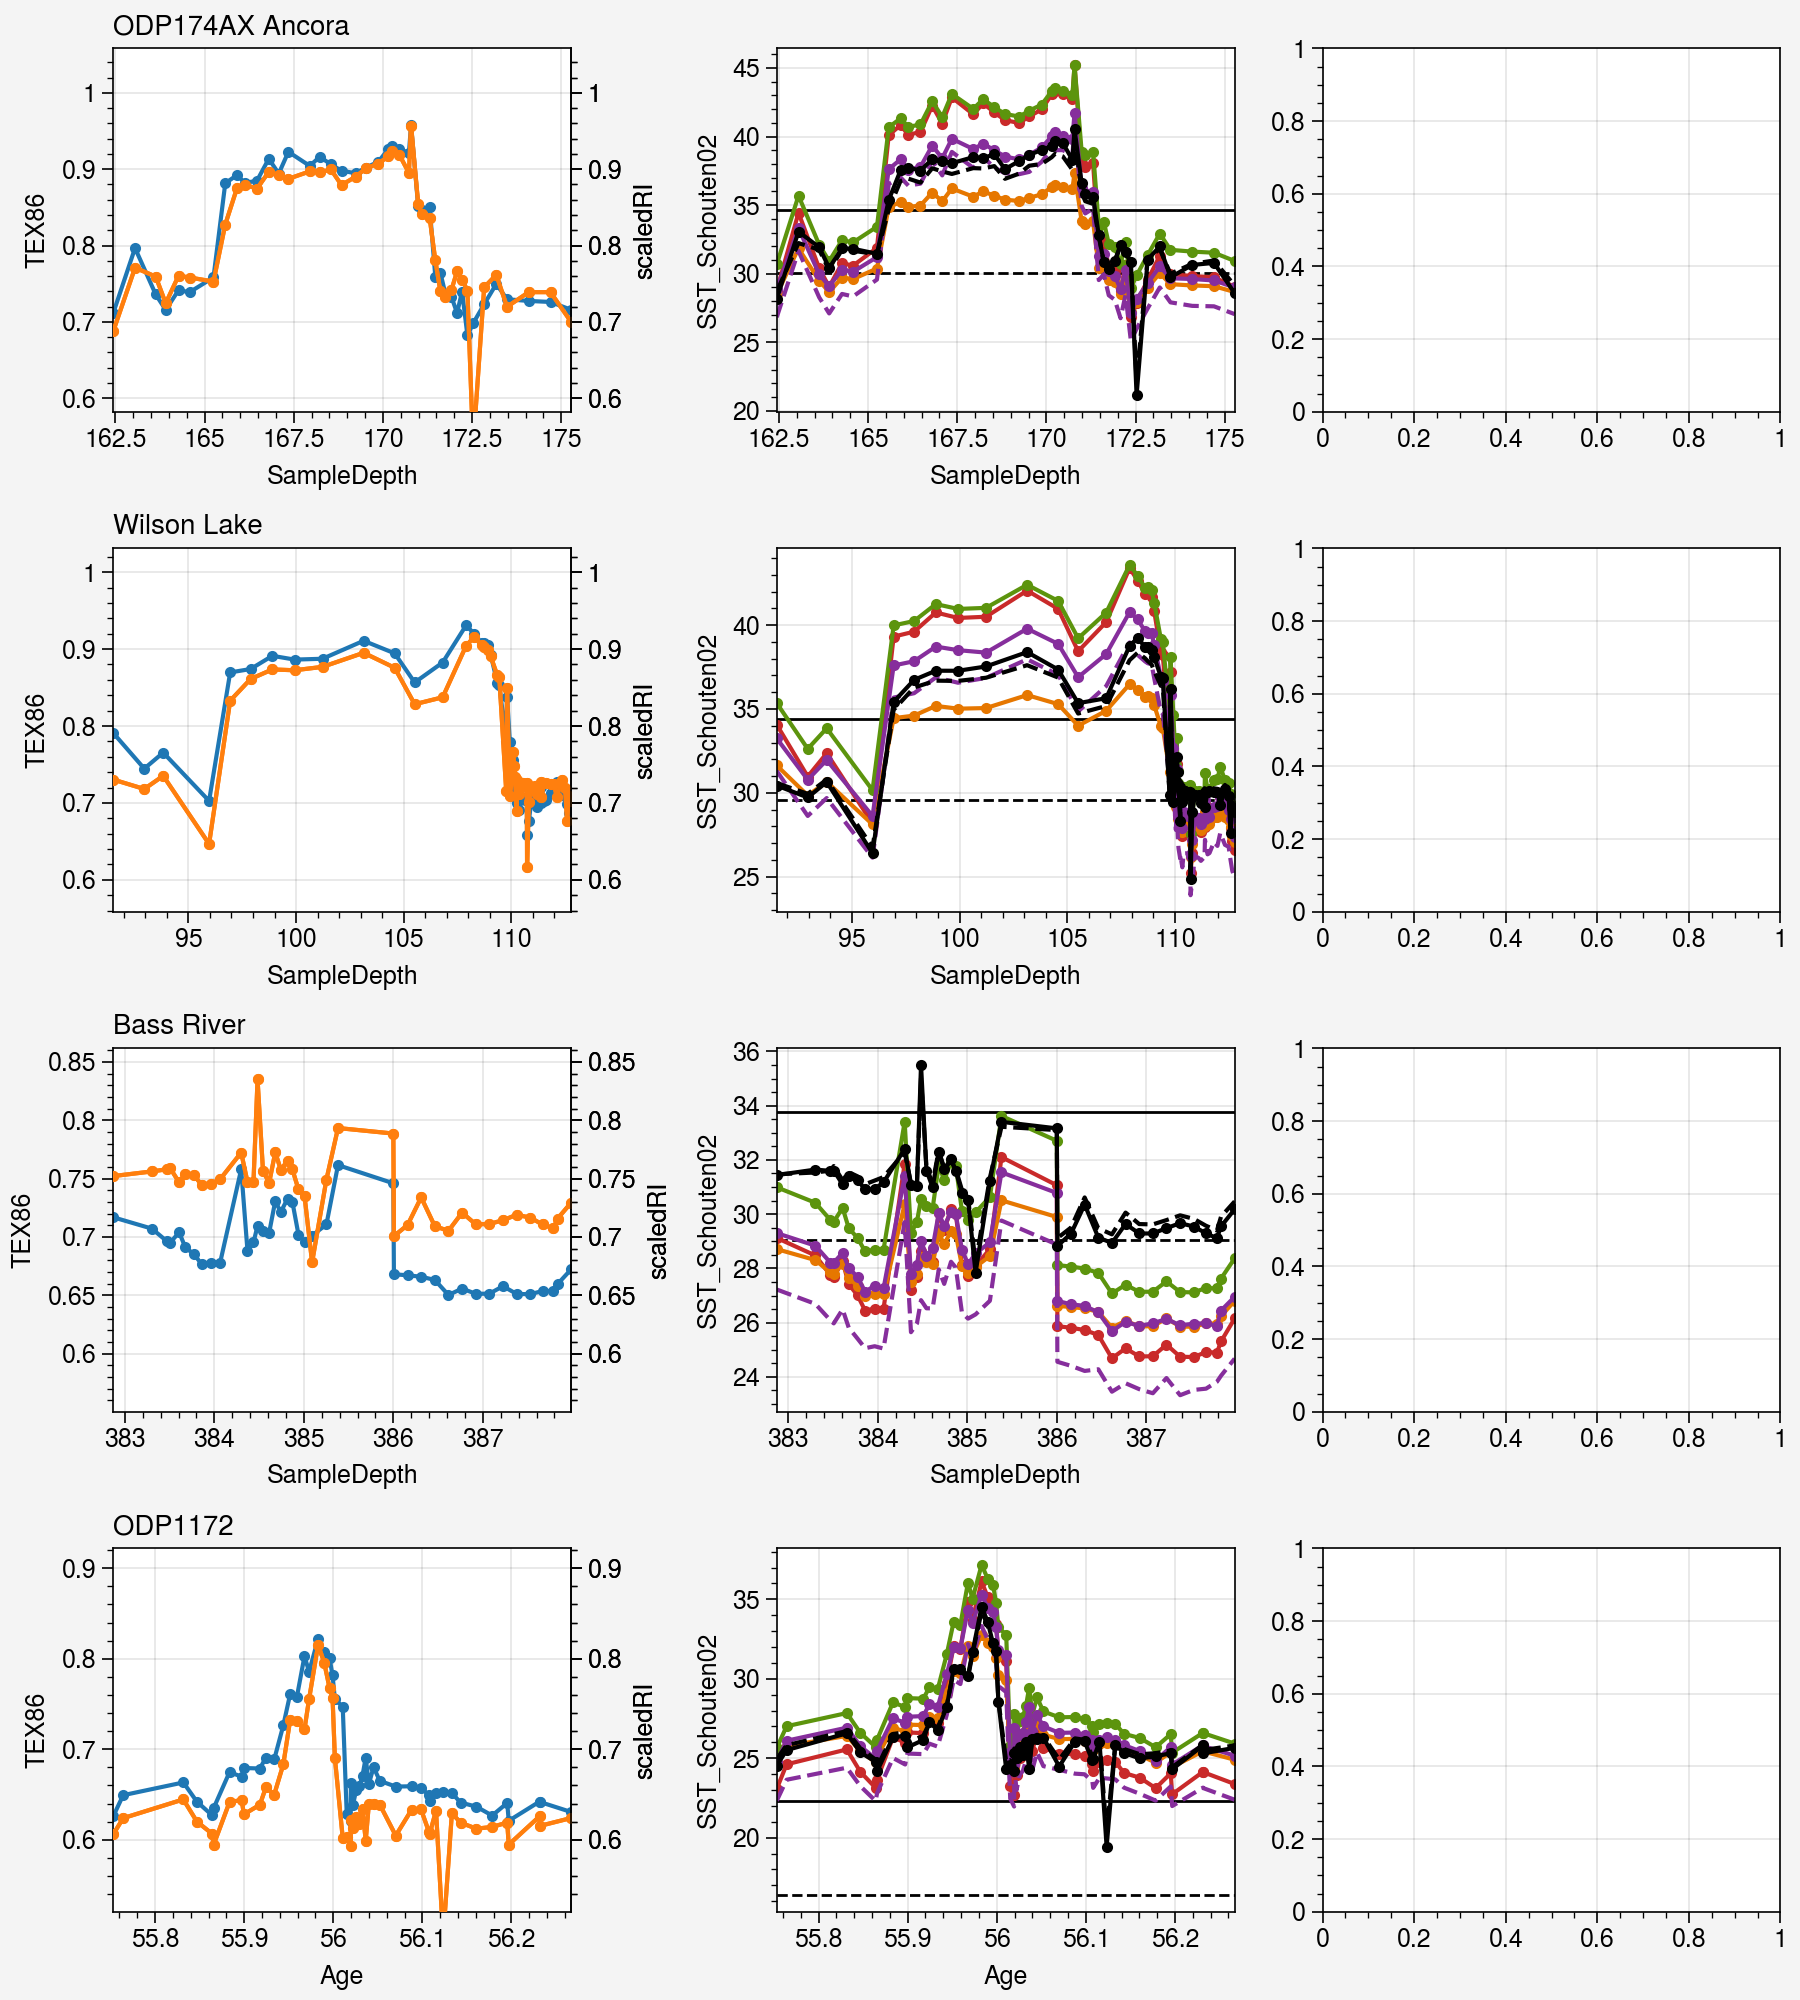

In [63]:
fig, axs = plot.subplots(width=9,nrows=len(site_names_list),ncols=3, height=10, share=0)

for i, site_name in enumerate(site_names_list):
    sel_site_df = plot_PhanTEX_df[plot_PhanTEX_df['SiteName']==site_name]
    search_tolerance = np.std(sel_site_df['TEX86'], ddof=1) * 2
    pred_bsr_sst = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30, prior_std=6,
            temptype='sst',search_tol=search_tolerance,
            nens=100).percentile(50)
    
    pred_bsr_subt = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30, prior_std=6,
            temptype='subt',search_tol=search_tolerance,
            nens=100).percentile(50)
    

    
    ###########
    
    
    prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0],
        lon=sel_site_df['paleolon'].values[0],
        method='nearest'
    ).isel(nTime=1).values
    
    PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0],
        lon=sel_site_df['paleolon'].values[0],
        method='nearest'
    ).isel(nTime=0).values
    
    ii = 1
    while np.isnan(prePETM_DA_temp):
        prePETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0]-ii,
        lon=sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).isel(nTime=1).values
        ii += 1
    
    ii = 1
    while np.isnan(PETM_DA_temp):
        PETM_DA_temp = PETMDA_ds_regridded['sst'].sel(
        lat=sel_site_df['paleolat'].values[0]-ii,
        lon=sel_site_df['paleolon'].values[0]+ii,
        method='nearest'
        ).isel(nTime=0).values
        ii += 1
        
    axs[i,1].axhline(prePETM_DA_temp, color='black', ls='--', lw=1, label='Pre-PETM DA SST')
    axs[i,1].axhline(PETM_DA_temp, color='k', ls='-', lw=1, label='PETM DA SST')
    
    if sel_site_df['SampleDepth'].isnull().all():
        plot_data = sel_site_df.sort_values('Age').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['Age'], plot_data['TEX86'], m='.', c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['Age'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        axs[i,1].plot(plot_data['Age'], pred_bsr_sst, m='.', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['Age'], pred_bsr_subt,ls='--', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['Age'], plot_data['pred_T_TEXAS_Tg23r'], m='.', 
                      label='', color='k')
        axs[i,1].plot(plot_data['Age'], plot_data['pred_T_TEXAS_Tonly'], ls='--', 
                      label='', color='k')
    else:
        plot_data = sel_site_df.sort_values('SampleDepth').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['SampleDepth'], plot_data['TEX86'], m='.', c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['SampleDepth'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        axs[i,1].plot(plot_data['SampleDepth'], pred_bsr_sst, m='.', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['SampleDepth'], pred_bsr_subt,ls='--', 
                      label='', color='grape9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['pred_T_TEXAS_Tg23r'], m='.', 
                      label='', color='k')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['pred_T_TEXAS_Tonly'], ls='--', 
                      label='', color='k')

    axs[i,0].format(ltitle=site_name)

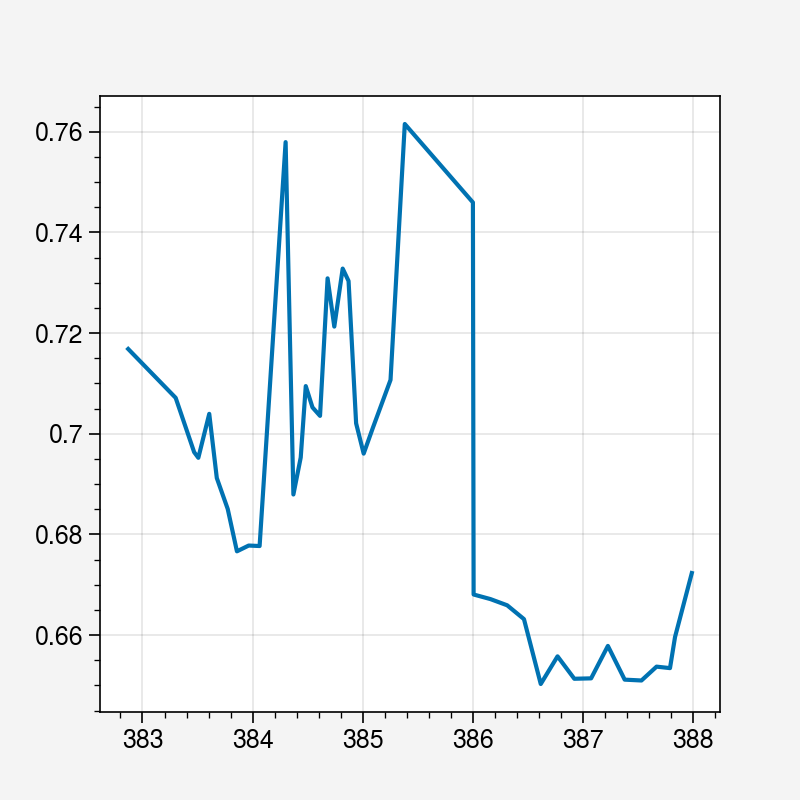

In [61]:
plot_y = PhanTEX_df[PhanTEX_df['SiteName']=='Bass River'][
    PhanTEX_df['SampleDepth'].between(380,390)
]['TEX86'].values
plot_x = PhanTEX_df[PhanTEX_df['SiteName']=='Bass River'][
    PhanTEX_df['SampleDepth'].between(380,390)
]['SampleDepth'].values
plt.plot(plot_x, plot_y)

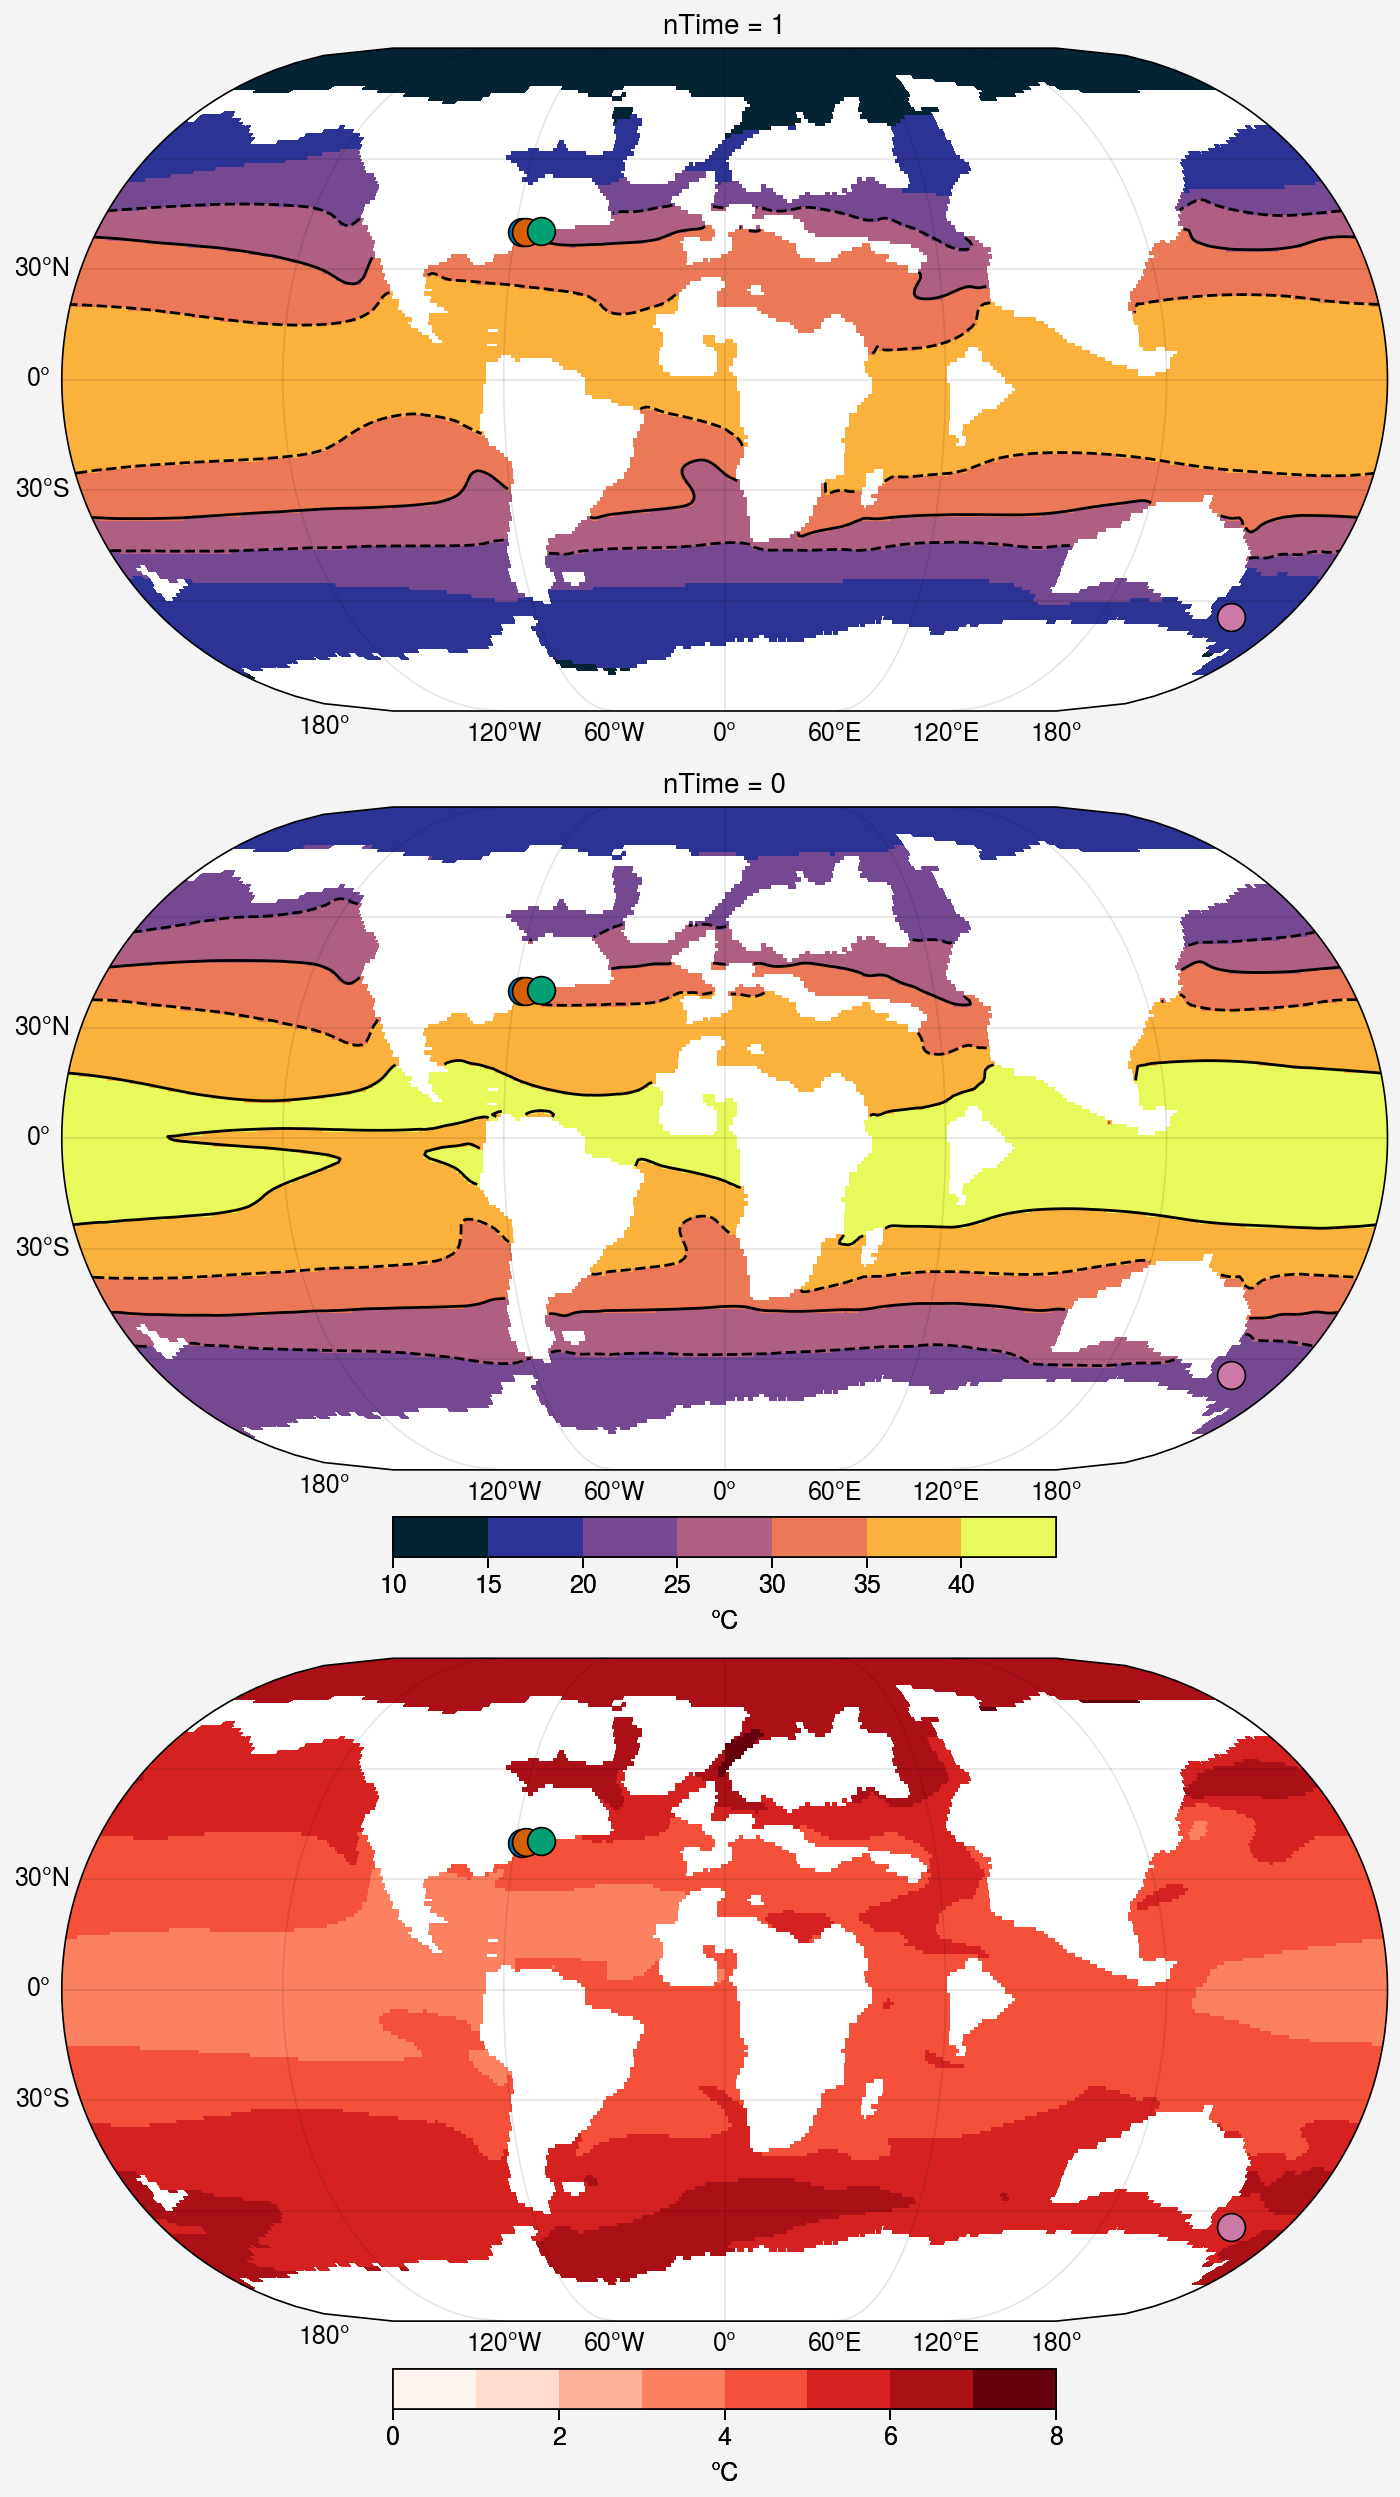

In [80]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

fig, axs = plot.subplots(width=7, proj='eck3',
                         nrows=3,
                         proj_kw={'lon_0':0},)

# Define consistent color levels and normalization
levels = np.arange(10, 45.1, 5)
cmap = plot.Colormap('thermal')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

### Pre-PETM
sc = PETMDA_ds_regridded['sst'].isel(nTime=1).plot.pcolormesh(
    ax=axs[0],
    cmap=cmap,
    norm=norm,  # Use explicit norm instead of levels
    add_colorbar=False
)

cs = axs[0].contour(
    PETMDA_ds_regridded['lon'],
    PETMDA_ds_regridded['lat'],
    PETMDA_ds_regridded['sst'].isel(nTime=1),
    levels=[25, 30, 35, 40],
    linestyle=['--', '-', '--', '-'],
    colors='k',
    linewidths=1,
)

### PETM DA
sc = PETMDA_ds_regridded['sst'].isel(nTime=0).plot.pcolormesh(
    ax=axs[1],
    cmap=cmap,
    norm=norm,  # Same norm object ensures identical mapping
    add_colorbar=False
)

cs = axs[1].contour(
    PETMDA_ds_regridded['lon'],
    PETMDA_ds_regridded['lat'],
    PETMDA_ds_regridded['sst'].isel(nTime=0),
    levels=[25, 30, 35, 40],
    linestyle=['--', '-', '--', '-'],
    colors='k',
    linewidths=1,
)
axs[1].colorbar(sc, label='°C', loc='b', shrink=0.5, ticks=np.arange(10, 41, 5))

### Difference plot
diff_levels = np.arange(0, 8.5, 1)
diff_norm = BoundaryNorm(diff_levels, ncolors=plot.Colormap('reds').N, clip=True)

sc_diff = (PETMDA_ds_regridded['sst'].isel(nTime=0) - 
           PETMDA_ds_regridded['sst'].isel(nTime=1)).plot.pcolormesh(
    ax=axs[2],
    cmap='reds',
    norm=diff_norm,
    add_colorbar=False
)
axs[2].colorbar(sc_diff, label='°C', loc='b', shrink=0.5)

for site_name in site_names_list:
    sel_site_df = plot_PhanTEX_df[plot_PhanTEX_df['SiteName']==site_name]
    lat = sel_site_df['paleolat'].unique()[0]
    lon = sel_site_df['paleolon'].unique()[0]
    
    axs.scatter(lon, lat, s=100, label=site_name, edgecolor='k', zorder=3)
    
axs.format(
    latlabels=True,
    lonlabels=True,
)